# Analisi di correlazione ERA5 &rarr; CAMS

**Obiettivo.** Quantificare la relazione tra i predittori meteorologici **ERA5** e le
concentrazioni di inquinanti modellate da **CAMS** (variabile dipendente), per chiudere
formalmente la fase di analisi esplorativa prima della costruzione del modello.

- **Predittori prioritari:** `era5_ssrd` (radiazione solare), `era5_blh` / `era5_blh_max`
  (altezza dello strato limite planetario, PBL). Poi `era5_t2m`, `era5_tp`.
- **Riferimento di controllo:** `vento_velocita`.
- **Inquinanti CAMS (dipendenti):** `cams_no2`, `cams_o3`, `cams_pm10`, `cams_pm25`.

> **Umidit&agrave; relativa.** Non &egrave; disponibile in questo dataset. Non viene stimata n&eacute;
> introdotta come proxy: la sua assenza &egrave; una limitazione dichiarata dell'analisi.

Le colonne `s5p_*` (Sentinel-5P) sono presenti nel file ma **non** rientrano in questa analisi,
che confronta ESCLUSIVAMENTE meteo ERA5 vs inquinanti CAMS.

## &#9888;&#65039; Avvertenze metodologiche (da leggere prima dei risultati)

Questi caveat valgono per **tutti** i coefficienti riportati nel notebook.

1. **ERA5 e CAMS non sono indipendenti.** CAMS &egrave; un modello di chimica-trasporto guidato
   dalla meteorologia IFS di ECMWF, la stessa famiglia da cui deriva ERA5. Le correlazioni
   riflettono **in parte la parametrizzazione interna di CAMS** e non solo una relazione
   fisica osservata. Sono utili per orientare la scelta dei predittori, non come prova causale.

2. **Autocorrelazione e medie mobili lunghe.** Con finestre di media mobile ampie le serie
   diventano fortemente autocorrelate: il numero di osservazioni **indipendenti** &egrave; molto
   minore di quello nominale e i coefficienti risultano **gonfiati**. Le `r` a MA lunga
   **non** vanno lette come potere predittivo giornaliero.

3. **Proxy temporali, non totali giornalieri reali.** `era5_ssrd` ed `era5_tp` qui derivano
   dalla somma di soli **4 istanti giornalieri** (00, 06, 12, 18 UTC): sono **proxy relativi**,
   non totali giornalieri veri. Analogamente `era5_blh_max` &egrave; il massimo su 4 istanti,
   non il vero massimo giornaliero.

4. **Correlazione bassa &ne; variabile inutile.** Pearson misura solo relazioni lineari; Spearman
   solo relazioni monotone. Un coefficiente basso **non giustifica** l'esclusione di una
   variabile dal modello (la relazione pu&ograve; essere non lineare, es. a U o a soglia).

## 0. Setup &mdash; librerie e configurazione

Vincoli tecnici: `pandas`, `numpy`, `matplotlib`; `seaborn` opzionale; `statsmodels` per VIF e
smoothing LOWESS. Codice vettorializzato, nessun loop riga per riga sui dati.

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display

# seaborn e' opzionale
try:
    import seaborn as sns
    HAS_SNS = True
    sns.set_theme(style="whitegrid", context="notebook")
except Exception:
    HAS_SNS = False
    print("seaborn non disponibile: uso matplotlib puro.")

# statsmodels per VIF e LOWESS
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
from statsmodels.nonparametric.smoothers_lowess import lowess

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

CSV_PATH = "serie_temporali_giornaliero_era5_corretto.csv"
OUT_DIR = Path("risultati_correlazione")
OUT_DIR.mkdir(exist_ok=True)
print("Output tabelle ->", OUT_DIR.resolve())

Output tabelle -> C:\Users\nsarmientoospina\Documents\REG4IA\risultati_correlazione


## 1. Caricamento e controllo qualit&agrave;

Cosa facciamo e come si legge:

- **Lettura robusta del separatore decimale.** Il file &egrave; `sep=";"`, `utf-8-sig`. Proviamo prima
  con `decimal="."`; se le coordinate (`lon`/`lat`) **non** risultano numeriche, significa che il
  decimale &egrave; la virgola e rileggiamo con `decimal=","`.
- **Copertura temporale e spaziale:** intervallo di date, numero di giorni e numero di punti,
  confronto con il prodotto atteso (punti &times; giorni).
- **Qualit&agrave;:** percentuale di NaN per colonna e per punto.
- **Conversioni di unit&agrave;** in colonne separate (senza sovrascrivere gli originali):
  `t2m` &rarr; &deg;C, `ssrd` &rarr; MJ/m&sup2;, `tp` &rarr; mm.

In [3]:
def _read(decimal):
    return pd.read_csv(CSV_PATH, sep=";", encoding="utf-8-sig", decimal=decimal)

# Tentativo 1: decimale con il punto
df = _read(".")
if not pd.api.types.is_numeric_dtype(df["lon"]):   # robusto anche con StringDtype (pandas recenti)
    print("Coordinate non numeriche con decimal='.'  ->  rileggo con decimal=','")
    df = _read(",")
else:
    print("Coordinate numeriche gia' con decimal='.'")

# ── Controllo automatico duplicati (data, punto_id) ────────────────
_n_dup = int(df.duplicated(subset=["data", "punto_id"]).sum())
assert _n_dup == 0, (
    f"Trovate {_n_dup} righe duplicate su (data, punto_id) in {CSV_PATH}: "
    "rigenerare/usare il file *_corretto.csv deduplicato."
)
print(f"Controllo duplicati OK: 0 duplicati su (data, punto_id) | righe = {len(df):,}")

print("Shape:", df.shape)
print("Colonne:", list(df.columns))
df.head()

Coordinate non numeriche con decimal='.'  ->  rileggo con decimal=','
Controllo duplicati OK: 0 duplicati su (data, punto_id) | righe = 454,060
Shape: (454060, 23)
Colonne: ['data', 'punto_id', 'lon', 'lat', 'vento_velocita', 'vento_direzione', 'cams_no2', 'cams_o3', 'cams_pm10', 'cams_pm25', 's5p_no2', 's5p_o3', 's5p_pm10', 's5p_pm25', 's5p_so2', 's5p_hcho', 'era5_t2m', 'era5_u10', 'era5_v10', 'era5_ssrd', 'era5_tp', 'era5_blh', 'era5_blh_max']


,data,punto_id,lon,lat,vento_velocita,vento_direzione,cams_no2,cams_o3,cams_pm10,cams_pm25,...,s5p_pm25,s5p_so2,s5p_hcho,era5_t2m,era5_u10,era5_v10,era5_ssrd,era5_tp,era5_blh,era5_blh_max
0,2025-01-01,0,10.2321,46.6205,0.5228,357.2186,3.4751,58.7846,8.0082,5.2332,...,-1.0515,-0.0012,-0.0002,265.2479,0.0254,-0.5222,"1,365,568.0000",0.0000,9.3751,9.9352
1,2025-01-01,1,10.1596,46.5897,0.5228,357.2186,2.9450,62.0998,6.3111,4.5079,...,-1.0952,-0.0008,0.0000,265.2479,0.0254,-0.5222,"1,365,568.0000",0.0000,9.3751,9.9352
2,2025-01-01,2,10.2314,46.5890,0.5228,357.2186,3.4751,58.7846,8.0082,5.2332,...,-1.0515,-0.0012,-0.0002,265.2479,0.0254,-0.5222,"1,365,568.0000",0.0000,9.3751,9.9352
3,2025-01-01,3,10.0872,46.5589,0.4611,19.8123,2.2896,59.0311,4.8817,3.6684,...,-1.0952,-0.0008,0.0000,265.3988,-0.1563,-0.4338,"1,361,920.0000",0.0000,9.4689,10.2477
4,2025-01-01,4,10.1589,46.5582,0.5228,357.2186,2.9450,62.0998,6.3111,4.5079,...,-1.0952,-0.0008,0.0000,265.2479,0.0254,-0.5222,"1,365,568.0000",0.0000,9.3751,9.9352


In [4]:
# Parsing date e verifica copertura
df["data"] = pd.to_datetime(df["data"], format="%Y-%m-%d", errors="coerce")
df["punto_id"] = df["punto_id"].astype(int)

n_days_span = (df["data"].max() - df["data"].min()).days + 1
n_punti = df["punto_id"].nunique()
print(f"Intervallo temporale : {df['data'].min().date()} -> {df['data'].max().date()}")
print(f"Giorni distinti      : {df['data'].nunique()}  (span calendario: {n_days_span})")
print(f"Punti distinti       : {n_punti}")
print(f"Righe totali         : {len(df):,}")
print(f"Righe attese (punti x giorni-span): {n_punti * n_days_span:,}")
dup = df.duplicated(subset=['data','punto_id']).sum()
print(f"Coppie (data, punto) duplicate: {dup:,}")

Intervallo temporale : 2025-01-01 -> 2025-12-31
Giorni distinti      : 365  (span calendario: 365)
Punti distinti       : 1244
Righe totali         : 454,060
Righe attese (punti x giorni-span): 454,060
Coppie (data, punto) duplicate: 0


In [5]:
# Percentuale di NaN per colonna
na_col = (df.isna().mean() * 100).round(3).sort_values(ascending=False)
print("NaN % per colonna:")
display(na_col.to_frame("perc_NaN"))

NaN % per colonna:


,perc_NaN
s5p_no2,16.1350
s5p_hcho,6.7720
s5p_so2,6.7500
s5p_o3,6.7500
s5p_pm25,5.7530
s5p_pm10,5.7530
vento_velocita,0.2740
cams_pm25,0.2740
vento_direzione,0.2740
cams_no2,0.0000


In [6]:
# Percentuale di NaN per punto (media sulle colonne numeriche di interesse)
cols_qc = ["cams_no2","cams_o3","cams_pm10","cams_pm25",
           "era5_t2m","era5_ssrd","era5_tp","era5_blh","era5_blh_max",
           "vento_velocita"]
na_pt = (df.groupby("punto_id")[cols_qc].apply(lambda g: g.isna().mean().mean()) * 100).round(3)
print("NaN % medio per punto - statistiche di sintesi:")
display(na_pt.describe().to_frame("perc_NaN_per_punto"))
print("\nPunti peggiori (piu' NaN):")
display(na_pt.sort_values(ascending=False).head(10).to_frame("perc_NaN"))

NaN % medio per punto - statistiche di sintesi:


,perc_NaN_per_punto
count,"1,244.0000"
mean,0.0550
std,0.0000
min,0.0550
25%,0.0550
50%,0.0550
75%,0.0550
max,0.0550



Punti peggiori (piu' NaN):


,perc_NaN
punto_id,
0,0.0550
1,0.0550
2,0.0550
3,0.0550
4,0.0550
5,0.0550
6,0.0550
7,0.0550
8,0.0550


In [7]:
# Conversioni di unita' in colonne SEPARATE (originali preservati)
df["era5_t2m_C"]  = df["era5_t2m"] - 273.15      # Kelvin -> gradi Celsius
df["era5_ssrd_MJ"] = df["era5_ssrd"] / 1e6       # J/m2   -> MJ/m2
df["era5_tp_mm"]   = df["era5_tp"] * 1000.0       # m      -> mm

check = df[["era5_t2m","era5_t2m_C","era5_ssrd","era5_ssrd_MJ","era5_tp","era5_tp_mm"]].describe().T
display(check[["mean","min","max"]])
print("\nNota: ssrd e tp sono somme di 4 istanti (00/06/12/18 UTC) -> proxy relativi, non totali giornalieri reali.")

,mean,min,max
era5_t2m,285.0639,252.1835,304.6660
era5_t2m_C,11.9139,-20.9665,31.5160
era5_ssrd,"2,153,744.5820","12,416.0000","4,914,240.0000"
era5_ssrd_MJ,2.1537,0.0124,4.9142
era5_tp,0.0006,0.0000,0.0358
era5_tp_mm,0.6148,0.0000,35.8338



Nota: ssrd e tp sono somme di 4 istanti (00/06/12/18 UTC) -> proxy relativi, non totali giornalieri reali.


In [8]:
# Definizione dei gruppi di variabili usati in tutto il notebook
PRED = ["era5_ssrd_MJ", "era5_blh", "era5_blh_max", "era5_t2m_C", "era5_tp_mm", "vento_velocita"]
POLL = ["cams_no2", "cams_o3", "cams_pm10", "cams_pm25"]

ETICHETTE = {
    "era5_ssrd_MJ": "SSRD [MJ/m2]", "era5_blh": "BLH [m]", "era5_blh_max": "BLH max [m]",
    "era5_t2m_C": "T2m [C]", "era5_tp_mm": "TP [mm]", "vento_velocita": "Vento [m/s]",
    "cams_no2": "NO2", "cams_o3": "O3", "cams_pm10": "PM10", "cams_pm25": "PM2.5",
}
print("Predittori:", PRED)
print("Inquinanti:", POLL)

Predittori: ['era5_ssrd_MJ', 'era5_blh', 'era5_blh_max', 'era5_t2m_C', 'era5_tp_mm', 'vento_velocita']
Inquinanti: ['cams_no2', 'cams_o3', 'cams_pm10', 'cams_pm25']


## 2. Statistiche descrittive e ciclo stagionale

Cosa facciamo e come si legge:

- **Statistiche descrittive** di predittori e inquinanti.
- **Climatologia mensile** (media per mese, su tutti i punti) di ogni predittore e di ogni
  inquinante CAMS.
- **Grafici del ciclo annuale.** Servono a rendere visibile la **stagionalit&agrave; condivisa**:
  se predittore e inquinante hanno lo stesso ciclo annuale, gran parte della loro correlazione
  &egrave; guidata dalla stagione (vedi Sezione 5, controllo obbligatorio).

In [9]:
display(df[PRED].describe().T[["mean","std","min","25%","50%","75%","max"]])
display(df[POLL].describe().T[["mean","std","min","25%","50%","75%","max"]])

,mean,std,min,25%,50%,75%,max
era5_ssrd_MJ,2.1537,1.2015,0.0124,1.2143,2.0051,3.1215,4.9142
era5_blh,298.7083,189.5576,9.3751,146.2299,277.0705,404.3667,"1,608.7404"
era5_blh_max,830.6908,511.5065,9.9352,404.3979,794.4460,"1,165.3684","3,639.5789"
era5_t2m_C,11.9139,8.6209,-20.9665,5.5171,11.3720,18.5764,31.5160
era5_tp_mm,0.6148,1.3537,0.0000,0.0000,0.0367,0.5236,35.8338
vento_velocita,0.9894,0.7231,0.0069,0.4735,0.8228,1.3116,8.0647


,mean,std,min,25%,50%,75%,max
cams_no2,12.1166,9.6089,0.4239,5.0236,9.1797,16.5817,66.9176
cams_o3,56.8802,27.0599,0.6237,37.8808,58.4823,76.0849,148.7017
cams_pm10,18.5781,13.7039,1.0161,8.8652,14.6201,24.3967,104.1442
cams_pm25,14.1343,12.2494,0.5566,5.9141,9.8228,18.2671,93.2979


In [10]:
# Climatologia mensile (media per mese su tutti i punti)
df["mese"] = df["data"].dt.month
clim_pred = df.groupby("mese")[PRED].mean()
clim_poll = df.groupby("mese")[POLL].mean()
print("Climatologia mensile - predittori:")
display(clim_pred)
print("Climatologia mensile - inquinanti CAMS:")
display(clim_poll)

Climatologia mensile - predittori:


,era5_ssrd_MJ,era5_blh,era5_blh_max,era5_t2m_C,era5_tp_mm,vento_velocita
mese,,,,,,
1,0.8859,108.5690,273.6388,1.9765,0.6045,0.9999
2,1.2737,166.8567,471.8402,3.6269,0.3031,0.9534
3,1.9831,296.0649,857.1438,7.3084,0.6112,0.9833
4,2.6731,399.1595,"1,127.0495",11.6783,0.6373,1.1470
5,3.1890,409.4410,"1,127.6020",15.1086,0.9384,1.0501
6,3.7415,466.4471,"1,274.1346",22.7443,0.3740,0.8514
7,3.5270,491.0519,"1,284.3290",21.1935,0.8201,0.9422
8,2.8922,411.6160,"1,143.3724",21.2633,1.0387,0.9818
9,2.0841,286.6832,883.0840,16.5978,0.7534,0.8683


Climatologia mensile - inquinanti CAMS:


,cams_no2,cams_o3,cams_pm10,cams_pm25
mese,,,,
1,21.9772,27.0440,28.1536,24.8057
2,19.0978,36.9897,32.9333,29.2858
3,13.1888,58.9633,18.5004,14.8214
4,8.3227,69.6286,15.3250,10.4290
5,6.4509,77.3940,11.8875,8.0429
6,6.4978,91.3656,18.4324,11.5518
7,6.4453,82.4298,10.6761,6.7402
8,6.3925,80.9383,13.9073,8.4800
9,8.1810,57.5804,11.5767,7.3796


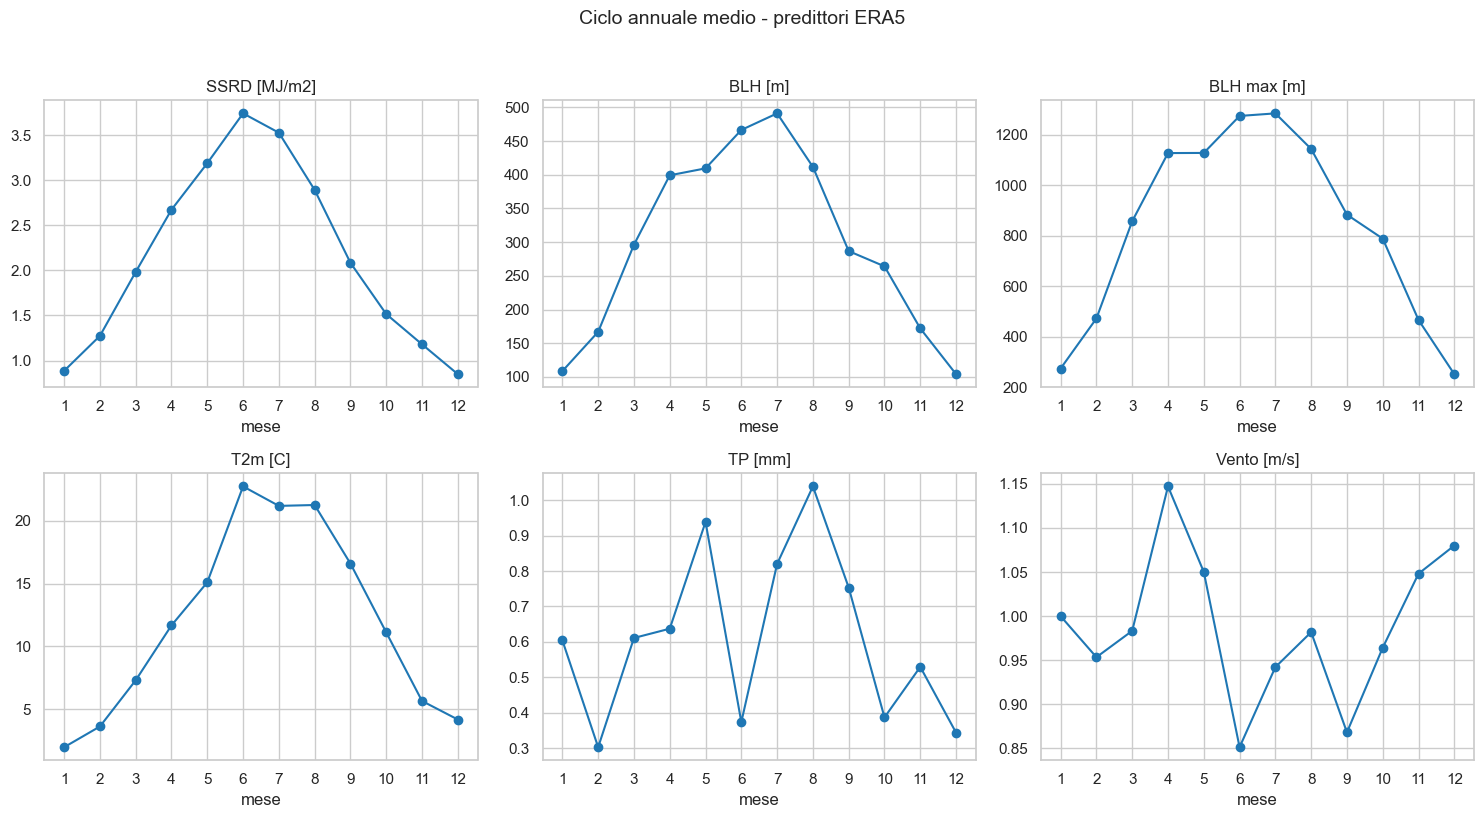

In [11]:
# Ciclo annuale dei predittori (un pannello per variabile, scale diverse)
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.ravel(), PRED):
    ax.plot(clim_pred.index, clim_pred[col], marker="o", color="tab:blue")
    ax.set_title(ETICHETTE[col]); ax.set_xlabel("mese"); ax.set_xticks(range(1,13))
fig.suptitle("Ciclo annuale medio - predittori ERA5", y=1.02, fontsize=14)
fig.tight_layout(); plt.show()

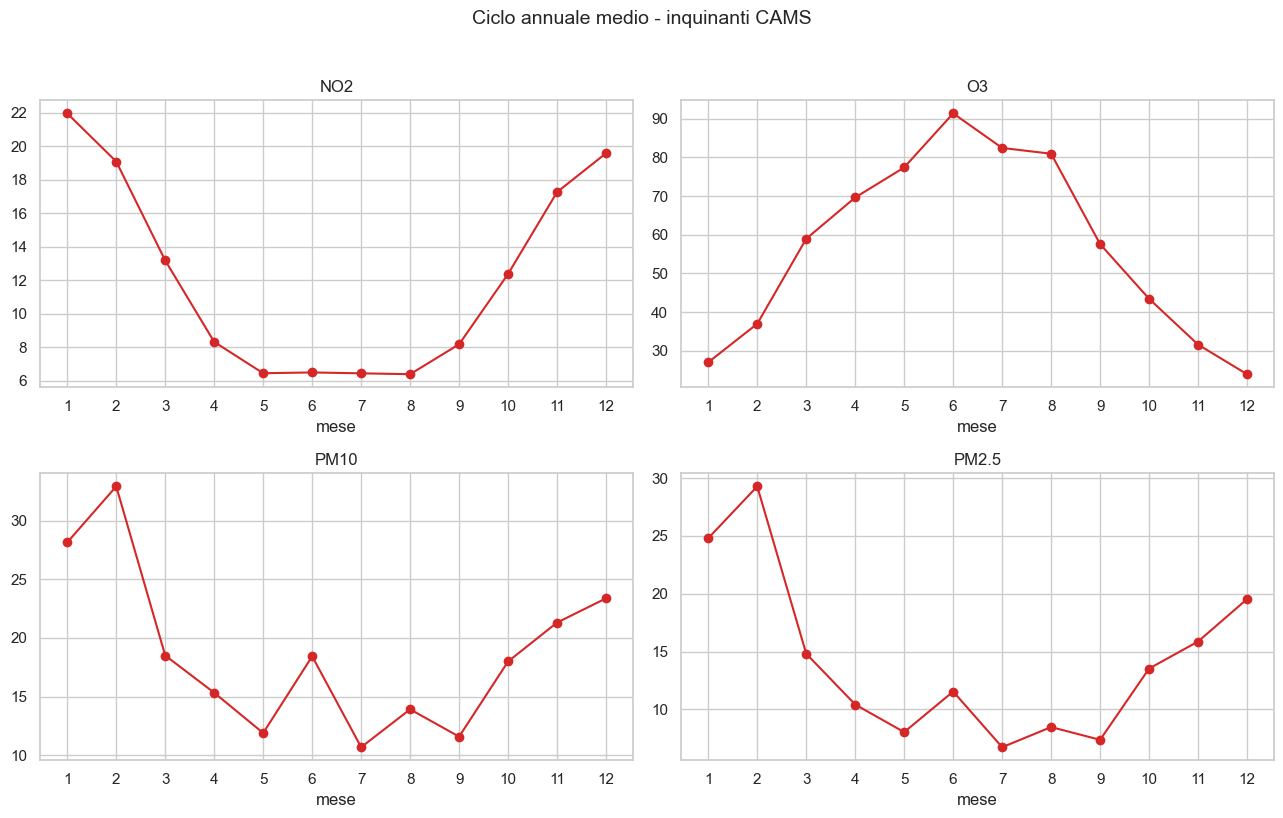

In [12]:
# Ciclo annuale degli inquinanti CAMS
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for ax, col in zip(axes.ravel(), POLL):
    ax.plot(clim_poll.index, clim_poll[col], marker="o", color="tab:red")
    ax.set_title(ETICHETTE[col]); ax.set_xlabel("mese"); ax.set_xticks(range(1,13))
fig.suptitle("Ciclo annuale medio - inquinanti CAMS", y=1.02, fontsize=14)
fig.tight_layout(); plt.show()

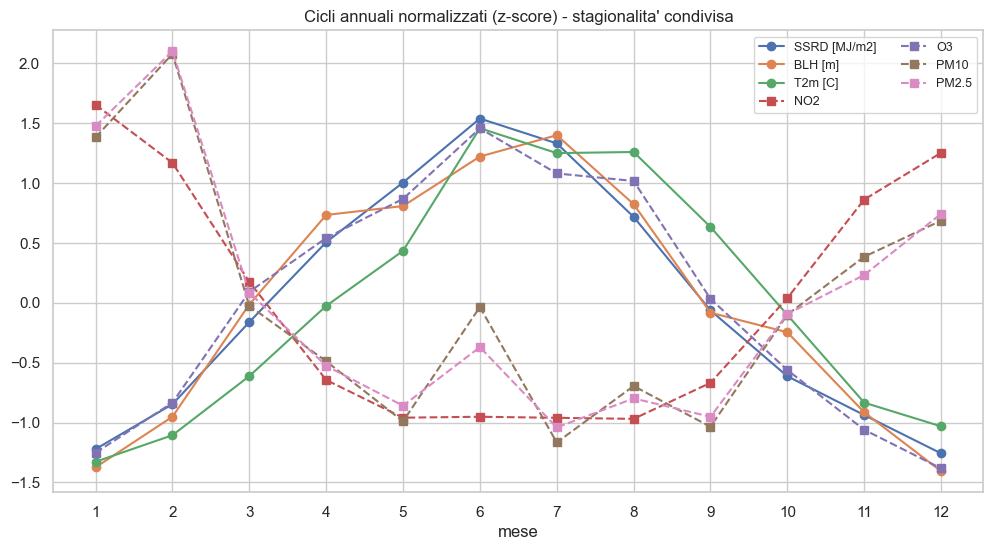

In [13]:
# Sovrapposizione normalizzata (z-score sulla climatologia) per vedere la stagionalita' condivisa
def zclim(c):
    return (c - c.mean()) / c.std()

fig, ax = plt.subplots(figsize=(12,6))
for col in ["era5_ssrd_MJ","era5_blh","era5_t2m_C"]:
    ax.plot(clim_pred.index, zclim(clim_pred[col]), marker="o", label=ETICHETTE[col])
for col in POLL:
    ax.plot(clim_poll.index, zclim(clim_poll[col]), marker="s", linestyle="--", label=ETICHETTE[col])
ax.set_title("Cicli annuali normalizzati (z-score) - stagionalita' condivisa")
ax.set_xlabel("mese"); ax.set_xticks(range(1,13)); ax.legend(ncol=2, fontsize=9); plt.show()

## 3. Correlazioni a lag 0

Cosa facciamo e come si legge:

- Matrice di correlazione **Pearson** (relazioni lineari) e **Spearman** (relazioni monotone)
  tra predittori ERA5 e inquinanti CAMS, allo stesso giorno (lag 0), sul pool di tutti i punti.
- **Heatmap** dei soli blocchi predittore &times; inquinante.
- Differenze marcate tra Pearson e Spearman segnalano **non linearit&agrave;** (approfondita in Sez. 6).

In [14]:
sub = df[PRED + POLL].dropna()
pear = sub.corr("pearson")
spear = sub.corr("spearman")
print(f"Osservazioni valide (righe complete): {len(sub):,}")

pear_block  = pear.loc[PRED, POLL]
spear_block = spear.loc[PRED, POLL]
print("Pearson (predittori x inquinanti):"); display(pear_block)
print("Spearman (predittori x inquinanti):"); display(spear_block)

Osservazioni valide (righe complete): 451,572
Pearson (predittori x inquinanti):


,cams_no2,cams_o3,cams_pm10,cams_pm25
era5_ssrd_MJ,-0.4662,0.8037,-0.2715,-0.3468
era5_blh,-0.4305,0.6100,-0.3324,-0.3802
era5_blh_max,-0.4451,0.6395,-0.3241,-0.3766
era5_t2m_C,-0.2362,0.6095,-0.0703,-0.1772
era5_tp_mm,-0.1115,-0.0095,-0.1862,-0.1677
vento_velocita,0.0370,-0.0387,-0.0487,-0.0502


Spearman (predittori x inquinanti):


,cams_no2,cams_o3,cams_pm10,cams_pm25
era5_ssrd_MJ,-0.4557,0.8258,-0.2099,-0.2860
era5_blh,-0.4088,0.6879,-0.2727,-0.3292
era5_blh_max,-0.4241,0.6983,-0.2554,-0.3147
era5_t2m_C,-0.1743,0.6384,0.0382,-0.0609
era5_tp_mm,-0.2073,0.0146,-0.2670,-0.2484
vento_velocita,0.1548,-0.1017,0.0125,0.0171


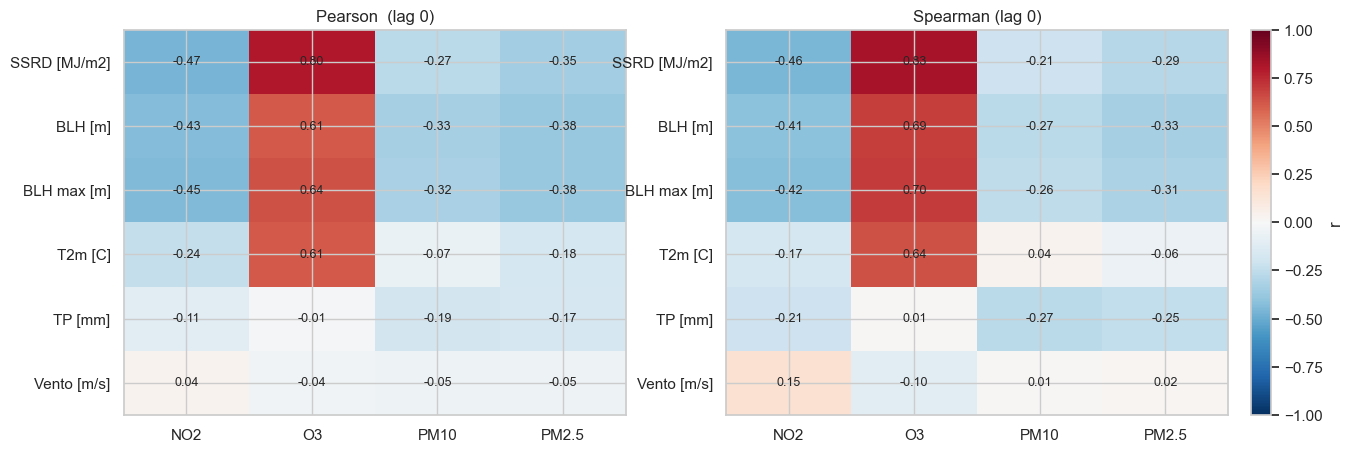

In [15]:
def heatmap(mat, title, ax):
    im = ax.imshow(mat.values, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
    ax.set_xticks(range(mat.shape[1])); ax.set_xticklabels([ETICHETTE[c] for c in mat.columns])
    ax.set_yticks(range(mat.shape[0])); ax.set_yticklabels([ETICHETTE[r] for r in mat.index])
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            ax.text(j, i, f"{mat.values[i,j]:.2f}", ha="center", va="center", fontsize=9)
    ax.set_title(title)
    return im

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
im = heatmap(pear_block, "Pearson  (lag 0)", axes[0])
heatmap(spear_block, "Spearman (lag 0)", axes[1])
fig.colorbar(im, ax=axes, fraction=0.03, pad=0.02, label="r")
plt.show()

## 4. Esplorazione lag &times; media mobile

Cosa facciamo e come si legge:

- **Calendario giornaliero continuo per punto.** Prima di applicare `shift` (lag) e `rolling`
  (media mobile) allineiamo ogni punto su un calendario giornaliero completo (reindex sul range
  di date). Senza questo passaggio i giorni mancanti disallineano le serie e i lag diventano
  errati.
- **Lag del predittore** da 0 a 14 giorni; **finestre di media mobile** [1, 3, 7, 14, 21, 30]
  giorni applicate al predittore.
- Correlazione (Pearson) calcolata **sul pool di tutti i punti**, riportando anche il **numero
  di osservazioni valide**.
- **Heatmap lag &times; finestra** per ogni coppia predittore-inquinante e **tabella** con la
  combinazione migliore (|r| massimo) per ogni coppia.

> &#9888;&#65039; **Autocorrelazione.** Le celle con finestra ampia (14-30 gg) hanno `r` pi&ugrave; alti ma
> molte meno osservazioni indipendenti: il valore &egrave; **gonfiato** e non rappresenta potere
> predittivo giornaliero. Confrontare sempre con la colonna del numero di osservazioni e con
> le anomalie (Sez. 5).

In [16]:
# Griglia temporale continua e pivot punto x data per ogni variabile
full_idx = pd.date_range(df["data"].min(), df["data"].max(), freq="D")
print(f"Calendario continuo: {full_idx.min().date()} -> {full_idx.max().date()}  ({len(full_idx)} giorni)")

def wide(col):
    """DataFrame date(righe continue) x punto_id(colonne) per la variabile col."""
    w = df.pivot_table(index="data", columns="punto_id", values=col, aggfunc="mean")
    return w.reindex(full_idx)

# Cache dei pivot (evita di ricalcolarli nei loop)
WIDE = {c: wide(c) for c in PRED + POLL}
print("Pivot pronti per:", list(WIDE.keys()))

Calendario continuo: 2025-01-01 -> 2025-12-31  (365 giorni)
Pivot pronti per: ['era5_ssrd_MJ', 'era5_blh', 'era5_blh_max', 'era5_t2m_C', 'era5_tp_mm', 'vento_velocita', 'cams_no2', 'cams_o3', 'cams_pm10', 'cams_pm25']


In [17]:
LAGS = list(range(0, 15))          # 0..14 giorni
WINS = [1, 3, 7, 14, 21, 30]        # finestre di media mobile (giorni)

def pooled_pearson(xw, yw):
    """Pearson sul pool di tutti i punti a partire da due matrici date x punto allineate."""
    x = xw.values.ravel(); y = yw.values.ravel()
    m = np.isfinite(x) & np.isfinite(y)
    n = int(m.sum())
    if n < 30:
        return np.nan, n
    xm, ym = x[m], y[m]
    xm = xm - xm.mean(); ym = ym - ym.mean()
    denom = np.sqrt((xm*xm).sum() * (ym*ym).sum())
    if denom == 0:
        return np.nan, n
    return float((xm*ym).sum() / denom), n

def lag_window_matrix(pred, poll):
    """Restituisce (R, N): matrici [len(WINS) x len(LAGS)] di r e n. Il predittore e' shiftato
    di 'lag' giorni (il predittore precede l'inquinante) e mediato su 'window' giorni."""
    yw = WIDE[poll]
    xw0 = WIDE[pred]
    R = np.full((len(WINS), len(LAGS)), np.nan)
    N = np.zeros((len(WINS), len(LAGS)), dtype=int)
    for i, w in enumerate(WINS):
        xs = xw0.rolling(w, min_periods=max(1, w // 2)).mean()   # media mobile sul predittore
        for j, lag in enumerate(LAGS):
            xl = xs.shift(lag)                                    # il predittore precede
            r, n = pooled_pearson(xl, yw)
            R[i, j] = r; N[i, j] = n
    return R, N

# Calcolo per tutte le coppie
RES = {}
for p in PRED:
    for q in POLL:
        RES[(p, q)] = lag_window_matrix(p, q)
print("Matrici lag x finestra calcolate per", len(RES), "coppie.")

Matrici lag x finestra calcolate per 24 coppie.


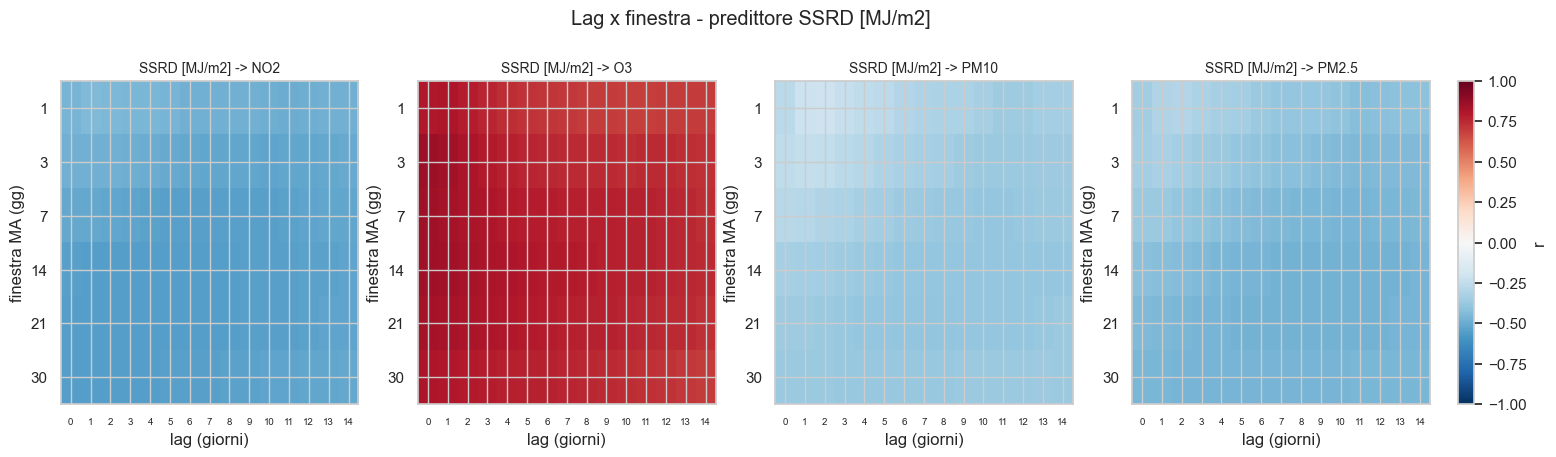

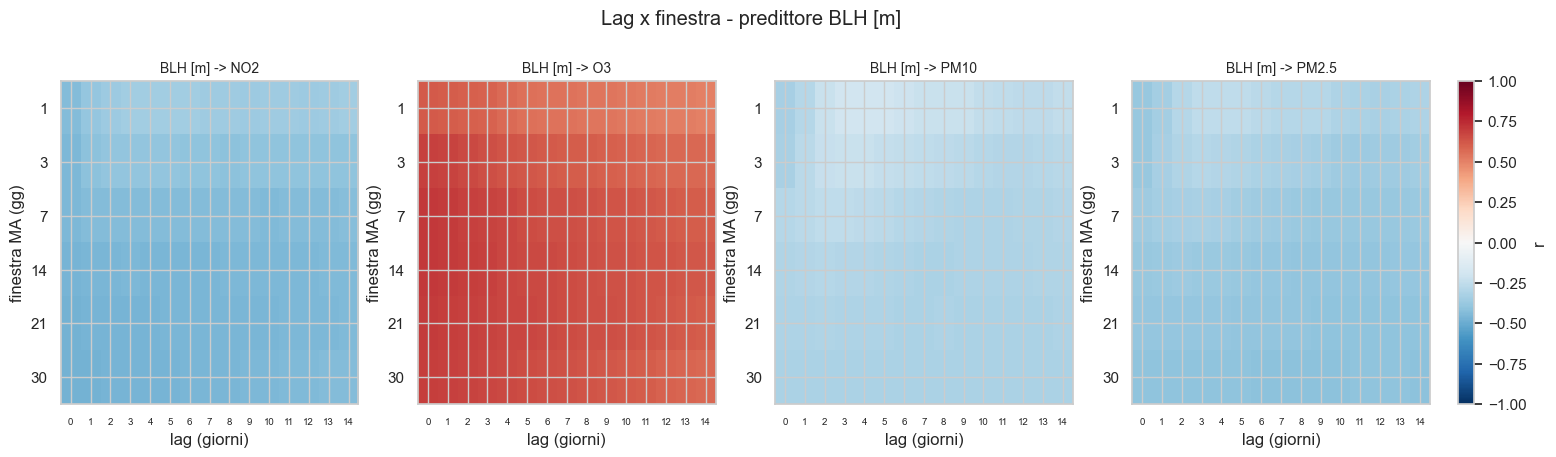

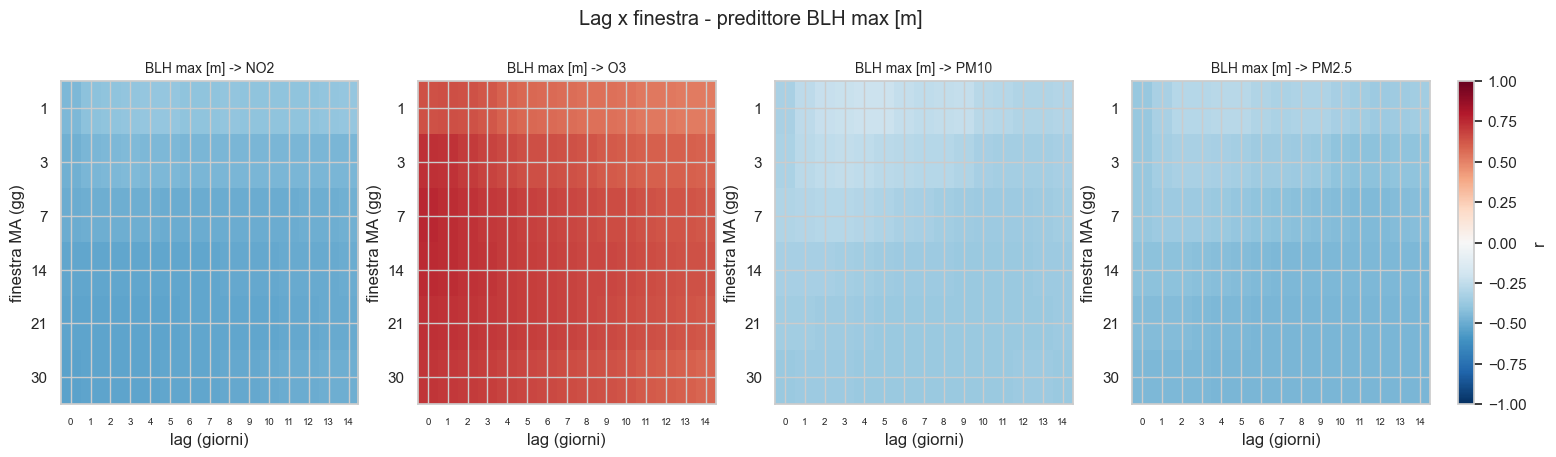

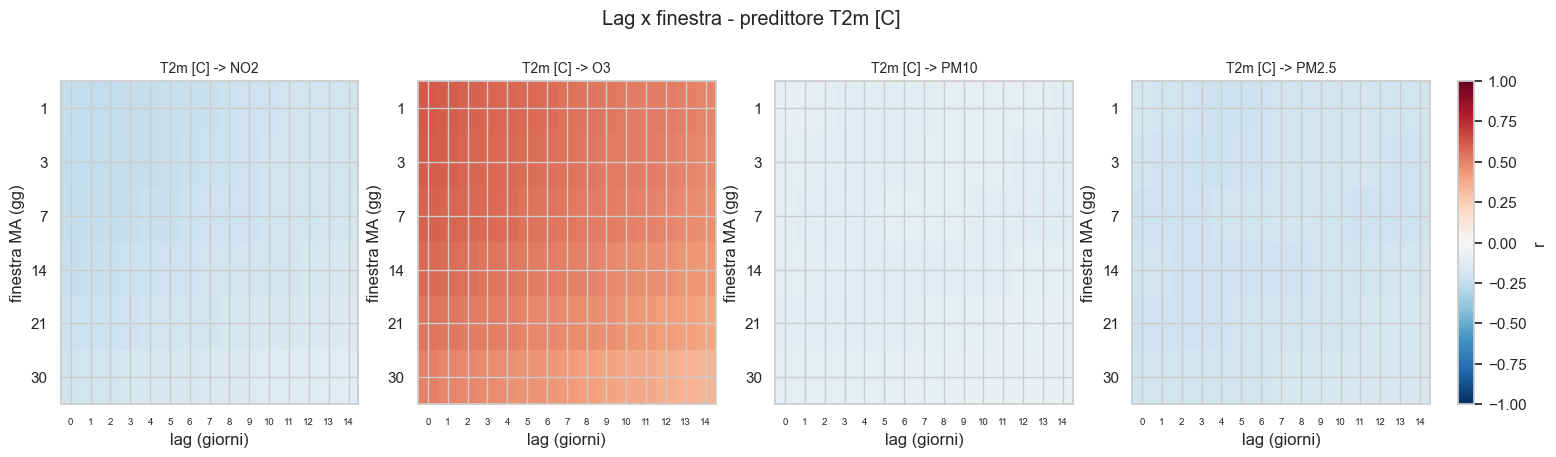

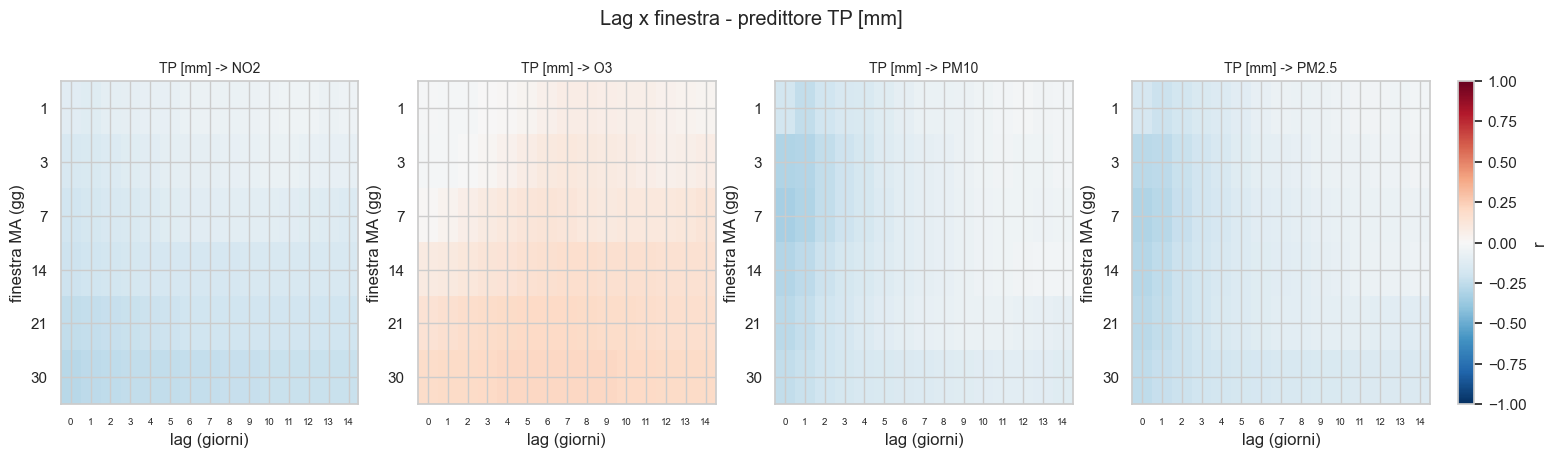

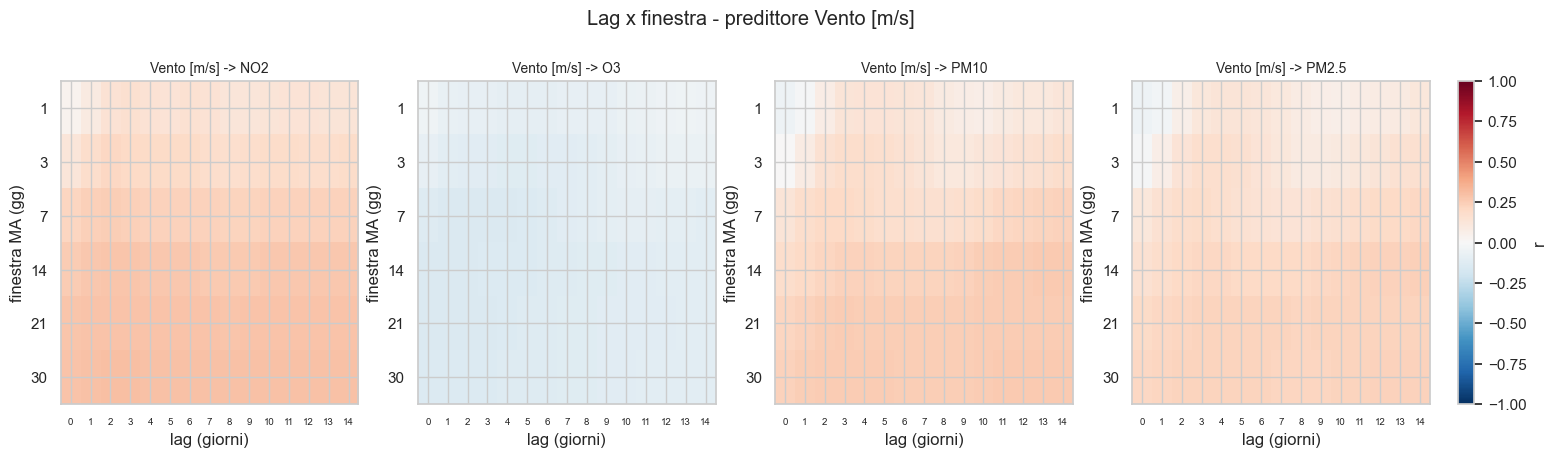

In [18]:
# Heatmap lag x finestra: una figura per predittore, un pannello per inquinante
for p in PRED:
    fig, axes = plt.subplots(1, len(POLL), figsize=(4.6*len(POLL), 4.2), squeeze=False)
    for ax, q in zip(axes[0], POLL):
        R, N = RES[(p, q)]
        im = ax.imshow(R, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
        ax.set_xticks(range(len(LAGS))); ax.set_xticklabels(LAGS, fontsize=7)
        ax.set_yticks(range(len(WINS))); ax.set_yticklabels(WINS)
        ax.set_xlabel("lag (giorni)"); ax.set_ylabel("finestra MA (gg)")
        ax.set_title(f"{ETICHETTE[p]} -> {ETICHETTE[q]}", fontsize=10)
    fig.colorbar(im, ax=axes.ravel().tolist(), fraction=0.02, pad=0.02, label="r")
    fig.suptitle(f"Lag x finestra - predittore {ETICHETTE[p]}", y=1.05)
    plt.show()

In [19]:
# Tabella con la combinazione migliore (|r| massimo) per ogni coppia
best_rows = []
for (p, q), (R, N) in RES.items():
    if np.all(np.isnan(R)):
        continue
    ii, jj = np.unravel_index(np.nanargmax(np.abs(R)), R.shape)
    best_rows.append({
        "predittore": p, "inquinante": q,
        "finestra_MA_gg": WINS[ii], "lag_gg": LAGS[jj],
        "r": round(R[ii, jj], 4), "n_oss": int(N[ii, jj]),
        "r_lag0_MA1": round(RES[(p, q)][0][0, 0], 4),  # riferimento giornaliero puro
    })
best_df = pd.DataFrame(best_rows).sort_values(["inquinante","predittore"]).reset_index(drop=True)
display(best_df)
best_df.to_csv(OUT_DIR / "best_lag_finestra.csv", index=False, sep=";", decimal=",")
print("Salvato:", OUT_DIR / "best_lag_finestra.csv")

,predittore,inquinante,finestra_MA_gg,lag_gg,r,n_oss,r_lag0_MA1
0,era5_blh,cams_no2,30,0,-0.4733,436644,-0.4306
1,era5_blh_max,cams_no2,30,0,-0.5336,436644,-0.4453
2,era5_ssrd_MJ,cams_no2,21,4,-0.5543,437888,-0.4665
3,era5_t2m_C,cams_no2,3,1,-0.2448,452816,-0.2360
4,era5_tp_mm,cams_no2,30,0,-0.2750,436644,-0.1103
5,vento_velocita,cams_no2,30,2,0.2980,434156,0.0376
6,era5_blh,cams_o3,7,0,0.7090,451572,0.6100
7,era5_blh_max,cams_o3,7,0,0.7531,451572,0.6398
8,era5_ssrd_MJ,cams_o3,3,0,0.8522,454060,0.8040
9,era5_t2m_C,cams_o3,1,0,0.6096,454060,0.6096


Salvato: risultati_correlazione\best_lag_finestra.csv


## 5. Controllo sulla stagionalit&agrave; (sezione obbligatoria)

La stagionalit&agrave; condivisa pu&ograve; gonfiare le correlazioni: sia il predittore sia l'inquinante
seguono lo stesso ciclo annuale, quindi correlano anche in assenza di un legame giornaliero.
Per separare l'effetto stagionale:

- **Anomalie.** Da ogni serie rimuoviamo la **climatologia mensile calcolata per punto**
  (media per `punto_id` &times; `mese`). La correlazione sulle anomalie misura il legame a parit&agrave;
  di stagione.
- **Stratificazione per stagione** (DJF, MAM, JJA, SON): ricalcoliamo la correlazione dentro
  ciascuna stagione.
- **Tabella di confronto** unica: `r` grezzo, `r` su anomalie, `r` per stagione.

Come si legge: se `r_anomalie` &laquo;crolla&raquo; rispetto a `r_grezzo`, gran parte della correlazione era
solo stagionalit&agrave; condivisa, non un legame giornaliero.

In [20]:
# Anomalie: rimozione della climatologia mensile PER PUNTO (vettorializzato)
VARS = PRED + POLL
clim_key = df.groupby(["punto_id","mese"])[VARS].transform("mean")
anom = df[VARS] - clim_key
anom.columns = [c + "_an" for c in VARS]
dfa = pd.concat([df[["data","punto_id","mese"]], anom], axis=1)

PRED_AN = [c + "_an" for c in PRED]
POLL_AN = [c + "_an" for c in POLL]
print("Colonne anomalie create. Esempio medie (attese ~0):")
display(dfa[PRED_AN + POLL_AN].mean().to_frame("media_anomalia"))

Colonne anomalie create. Esempio medie (attese ~0):


,media_anomalia
era5_ssrd_MJ_an,-0.0000
era5_blh_an,0.0000
era5_blh_max_an,0.0000
era5_t2m_C_an,0.0000
era5_tp_mm_an,-0.0000
vento_velocita_an,0.0000
cams_no2_an,0.0000
cams_o3_an,0.0000
cams_pm10_an,0.0000
cams_pm25_an,0.0000


In [21]:
# Stagioni meteorologiche
def to_season(m):
    return ("DJF" if m in (12,1,2) else "MAM" if m in (3,4,5)
            else "JJA" if m in (6,7,8) else "SON")
df["stagione"] = df["mese"].map(to_season)
STAG = ["DJF","MAM","JJA","SON"]

def pearson_cols(frame, a, b):
    s = frame[[a, b]].dropna()
    if len(s) < 30:
        return np.nan
    return float(s[a].corr(s[b]))

rows = []
for p in PRED:
    for q in POLL:
        r_raw  = pearson_cols(df, p, q)
        r_anom = pearson_cols(dfa, p + "_an", q + "_an")
        rec = {"predittore": p, "inquinante": q,
               "r_grezzo": round(r_raw, 4), "r_anomalie": round(r_anom, 4)}
        for s in STAG:
            sub_s = df[df["stagione"] == s]
            rec["r_" + s] = round(pearson_cols(sub_s, p, q), 4)
        rows.append(rec)

season_df = pd.DataFrame(rows)
display(season_df)
season_df.to_csv(OUT_DIR / "confronto_stagionalita.csv", index=False, sep=";", decimal=",")
print("Salvato:", OUT_DIR / "confronto_stagionalita.csv")

,predittore,inquinante,r_grezzo,r_anomalie,r_DJF,r_MAM,r_JJA,r_SON
0,era5_ssrd_MJ,cams_no2,-0.4665,-0.0140,-0.2074,-0.2126,0.2027,-0.2782
1,era5_ssrd_MJ,cams_o3,0.8040,0.4579,0.4584,0.6031,0.4471,0.5763
2,era5_ssrd_MJ,cams_pm10,-0.2724,0.0775,-0.0818,-0.0342,0.2763,-0.2195
3,era5_ssrd_MJ,cams_pm25,-0.3474,0.0604,-0.0789,-0.0824,0.2590,-0.2324
4,era5_blh,cams_no2,-0.4306,-0.3403,0.0170,-0.2633,0.0589,-0.3239
5,era5_blh,cams_o3,0.6100,0.2314,0.0761,0.3397,-0.0045,0.3716
6,era5_blh,cams_pm10,-0.3325,-0.2933,0.0204,-0.2599,-0.0579,-0.3474
7,era5_blh,cams_pm25,-0.3807,-0.2962,0.0332,-0.2896,-0.0843,-0.3430
8,era5_blh_max,cams_no2,-0.4453,-0.2212,0.0016,-0.2381,0.0289,-0.3225
9,era5_blh_max,cams_o3,0.6398,0.2785,0.1421,0.4045,0.0508,0.4242


Salvato: risultati_correlazione\confronto_stagionalita.csv


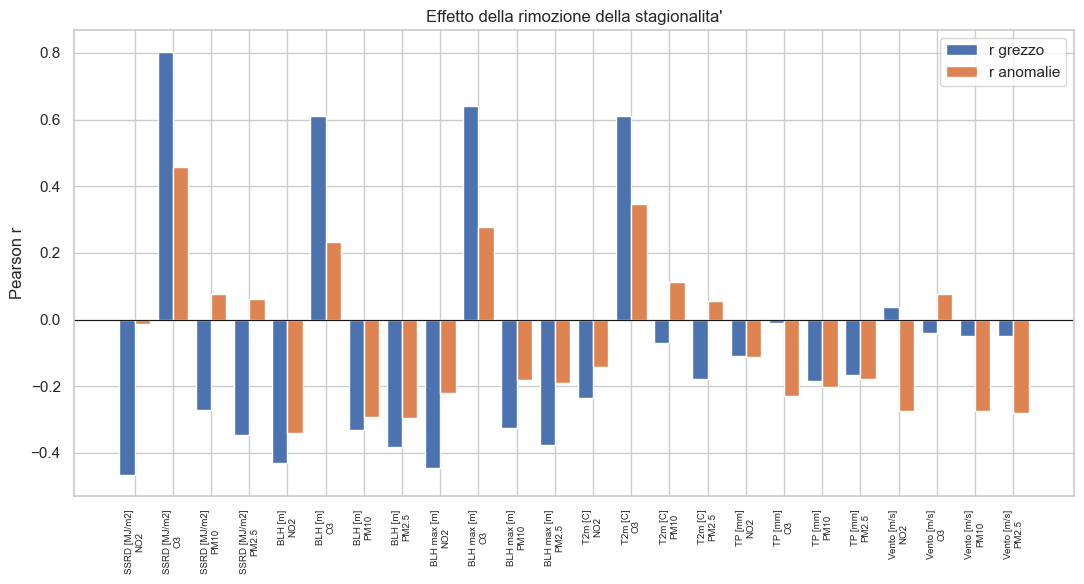

In [22]:
# Visualizzazione: r grezzo vs r su anomalie (quanto "crolla" togliendo la stagione)
fig, ax = plt.subplots(figsize=(11,6))
x = np.arange(len(season_df))
ax.bar(x - 0.2, season_df["r_grezzo"], width=0.4, label="r grezzo")
ax.bar(x + 0.2, season_df["r_anomalie"], width=0.4, label="r anomalie")
ax.axhline(0, color="k", lw=0.8)
ax.set_xticks(x)
ax.set_xticklabels([f"{ETICHETTE[r.predittore]}\n{ETICHETTE[r.inquinante]}"
                    for r in season_df.itertuples()], rotation=90, fontsize=7)
ax.set_ylabel("Pearson r"); ax.set_title("Effetto della rimozione della stagionalita'")
ax.legend(); plt.tight_layout(); plt.show()

## 6. Relazioni non lineari

Pearson coglie solo la parte lineare. Qui verifichiamo tre relazioni note in fisica
dell'atmosfera:

- **PBL (`era5_blh`) - relazione inversa.** Pi&ugrave; alto lo strato di rimescolamento, pi&ugrave; diluiti gli
  inquinanti: la relazione &egrave; di tipo `1/BLH`. Confrontiamo `r` su `BLH` vs `r` su `1/BLH`.
- **Precipitazione - forte asimmetria.** `tp` &egrave; quasi sempre nulla; oltre alla versione continua
  usiamo una **versione binaria** (pioggia s&igrave;/no) e confrontiamo le medie di inquinante.
- **Temperatura - possibile relazione a U con il PM.** Non basta il coefficiente lineare: usiamo
  **medie per bin di temperatura** e uno **scatter con curva smooth (LOWESS)**.

In [23]:
# 6a. BLH vs 1/BLH
df["inv_blh"] = 1.0 / df["era5_blh"].where(df["era5_blh"] > 0)
rows = []
for q in POLL:
    r_lin = pearson_cols(df, "era5_blh", q)
    r_inv = pearson_cols(df, "inv_blh", q)
    rows.append({"inquinante": q, "r(BLH)": round(r_lin,4), "r(1/BLH)": round(r_inv,4),
                 "|1/BLH| migliore?": abs(r_inv) > abs(r_lin)})
display(pd.DataFrame(rows))
print("Atteso: 1/BLH correla positivamente con gli inquinanti (meno rimescolamento -> piu' concentrazione).")

,inquinante,r(BLH),r(1/BLH),|1/BLH| migliore?
0,cams_no2,-0.4306,0.1699,False
1,cams_o3,0.6100,-0.3475,False
2,cams_pm10,-0.3325,0.0888,False
3,cams_pm25,-0.3807,0.1266,False


Atteso: 1/BLH correla positivamente con gli inquinanti (meno rimescolamento -> piu' concentrazione).


In [24]:
# 6b. Precipitazione: continua vs binaria (pioggia si'/no)
SOGLIA_MM = 0.1
df["pioggia_bin"] = (df["era5_tp_mm"] > SOGLIA_MM).astype(int)
print(f"Frazione di giorni-punto con pioggia (> {SOGLIA_MM} mm): {df['pioggia_bin'].mean():.1%}")

rows = []
for q in POLL:
    r_cont = pearson_cols(df, "era5_tp_mm", q)
    r_bin  = pearson_cols(df, "pioggia_bin", q)       # point-biserial
    m0 = df.loc[df["pioggia_bin"] == 0, q].mean()
    m1 = df.loc[df["pioggia_bin"] == 1, q].mean()
    rows.append({"inquinante": q, "r(tp continua)": round(r_cont,4),
                 "r(pioggia si/no)": round(r_bin,4),
                 "media_no_pioggia": round(m0,3), "media_pioggia": round(m1,3),
                 "delta_%": round(100*(m1-m0)/m0, 1)})
display(pd.DataFrame(rows))

Frazione di giorni-punto con pioggia (> 0.1 mm): 41.4%


,inquinante,r(tp continua),r(pioggia si/no),media_no_pioggia,media_pioggia,delta_%
0,cams_no2,-0.1103,-0.1605,13.4120,10.2800,-23.3000
1,cams_o3,-0.0110,-0.0116,57.1440,56.5060,-1.1000
2,cams_pm10,-0.1849,-0.2269,21.1900,14.8760,-29.8000
3,cams_pm25,-0.1670,-0.2020,16.2170,11.1950,-31.0000


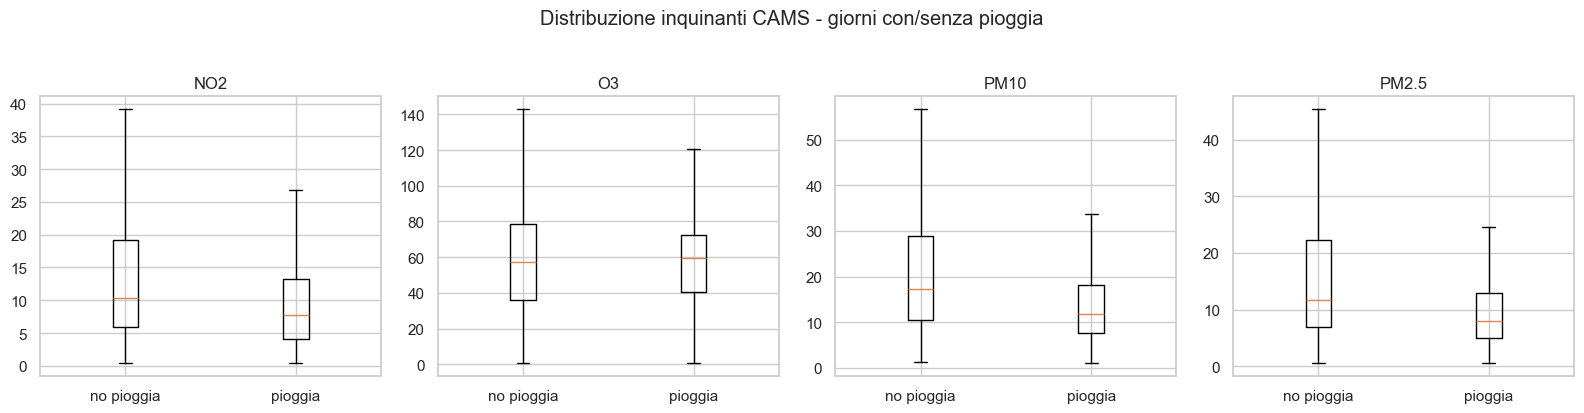

In [25]:
# 6b-bis. Boxplot inquinanti per giorni con/senza pioggia
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, q in zip(axes, POLL):
    data = [df.loc[df.pioggia_bin==0, q].dropna(), df.loc[df.pioggia_bin==1, q].dropna()]
    ax.boxplot(data, labels=["no pioggia","pioggia"], showfliers=False)
    ax.set_title(ETICHETTE[q])
fig.suptitle("Distribuzione inquinanti CAMS - giorni con/senza pioggia", y=1.03)
plt.tight_layout(); plt.show()

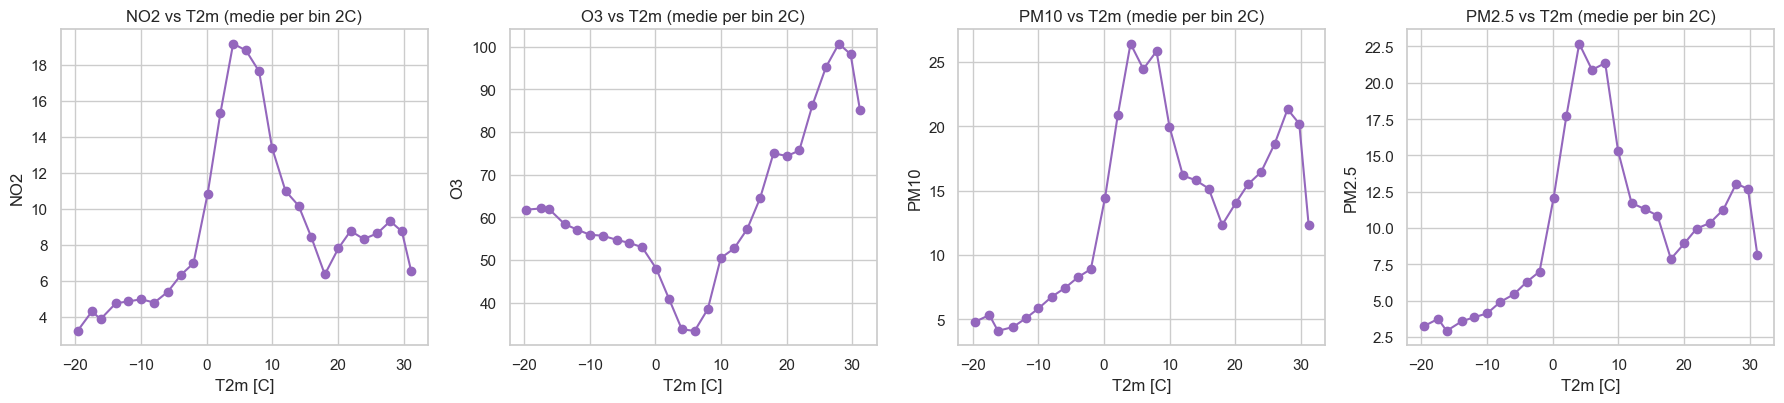

In [26]:
# 6c. Temperatura: medie per bin + scatter con LOWESS (relazione potenzialmente a U per il PM)
bins = np.arange(np.floor(df["era5_t2m_C"].min()), np.ceil(df["era5_t2m_C"].max()) + 2, 2.0)
df["t2m_bin"] = pd.cut(df["era5_t2m_C"], bins)
binned = df.groupby("t2m_bin")[POLL].mean()
centers = df.groupby("t2m_bin")["era5_t2m_C"].mean()

fig, axes = plt.subplots(1, 4, figsize=(18, 4.2))
for ax, q in zip(axes, POLL):
    ax.plot(centers.values, binned[q].values, marker="o", color="tab:purple")
    ax.set_title(f"{ETICHETTE[q]} vs T2m (medie per bin 2C)")
    ax.set_xlabel("T2m [C]"); ax.set_ylabel(ETICHETTE[q])
plt.tight_layout(); plt.show()

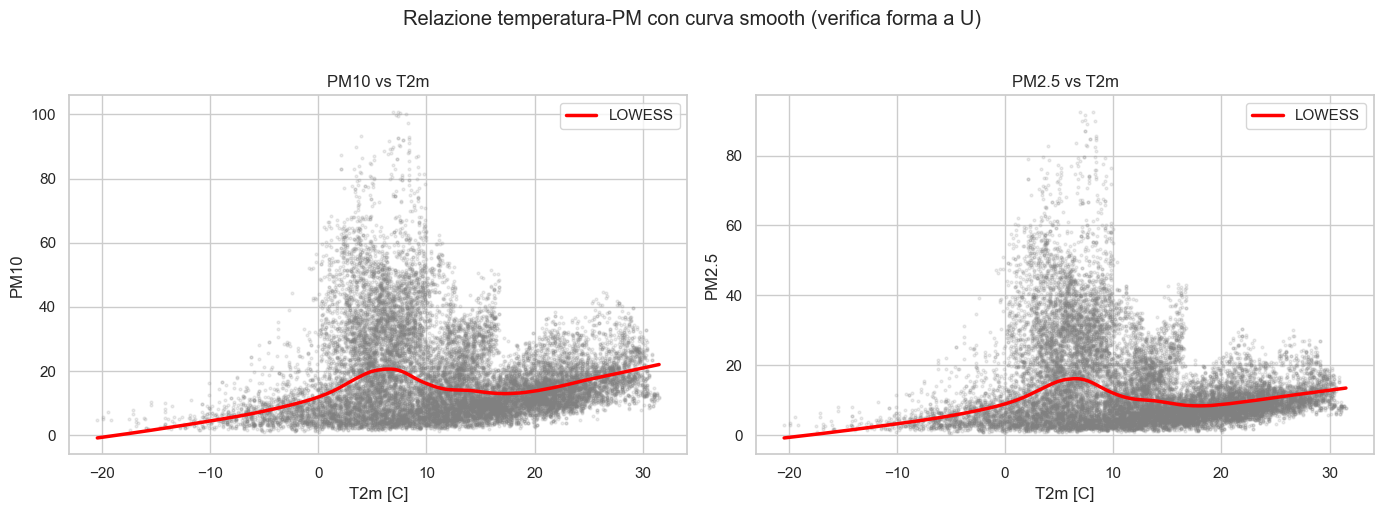

In [27]:
# 6c-bis. Scatter campionato + curva LOWESS per PM10 e PM2.5 (dove ci si aspetta la U)
rng = np.random.default_rng(0)
samp = df[["era5_t2m_C","cams_pm10","cams_pm25"]].dropna()
if len(samp) > 20000:
    samp = samp.iloc[rng.choice(len(samp), 20000, replace=False)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, q in zip(axes, ["cams_pm10","cams_pm25"]):
    ax.scatter(samp["era5_t2m_C"], samp[q], s=4, alpha=0.15, color="grey")
    lo = lowess(samp[q], samp["era5_t2m_C"], frac=0.3, return_sorted=True)
    ax.plot(lo[:,0], lo[:,1], color="red", lw=2.5, label="LOWESS")
    ax.set_title(f"{ETICHETTE[q]} vs T2m"); ax.set_xlabel("T2m [C]"); ax.set_ylabel(ETICHETTE[q])
    ax.legend()
fig.suptitle("Relazione temperatura-PM con curva smooth (verifica forma a U)", y=1.02)
plt.tight_layout(); plt.show()

## 6d. Grafici di dispersione predittore &times; inquinante

Scatter (campionati per leggibilit&agrave;) di ogni predittore contro ogni inquinante CAMS, con curva
**LOWESS** sovrapposta. Servono a ispezionare **la forma** della relazione (lineare, inversa,
a soglia, a U), non solo il segno del coefficiente.

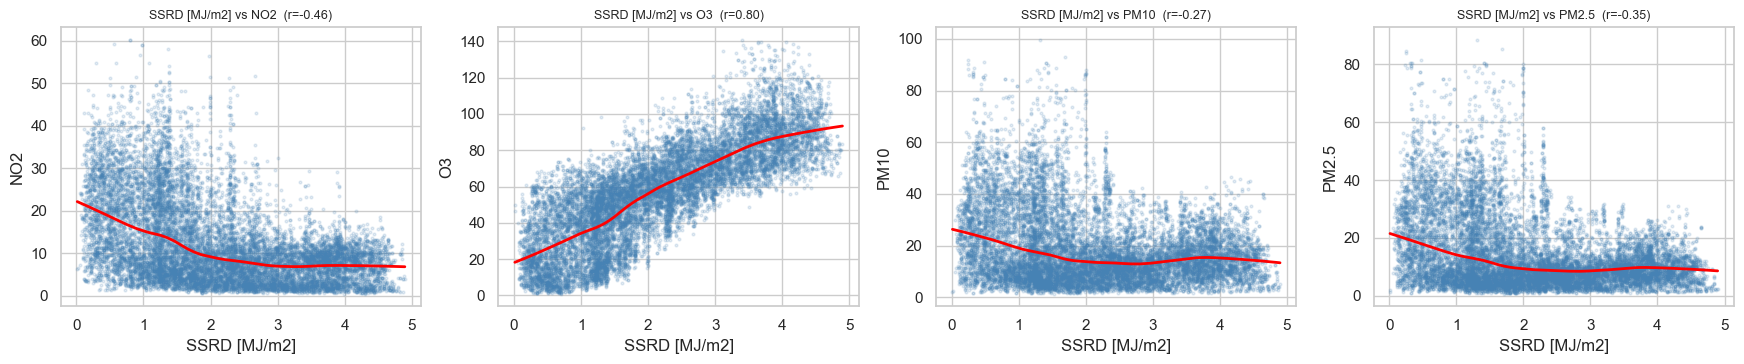

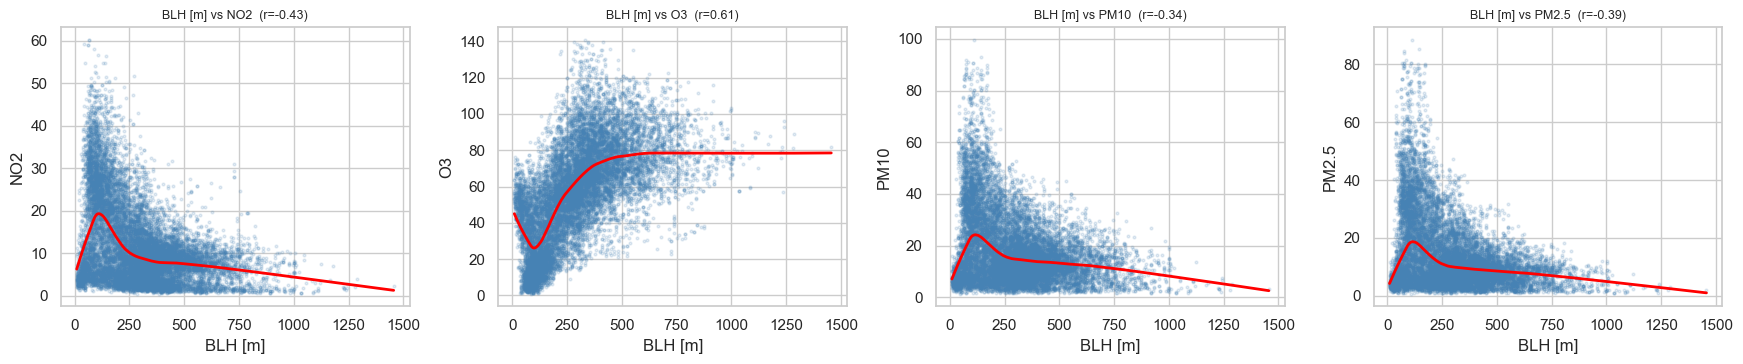

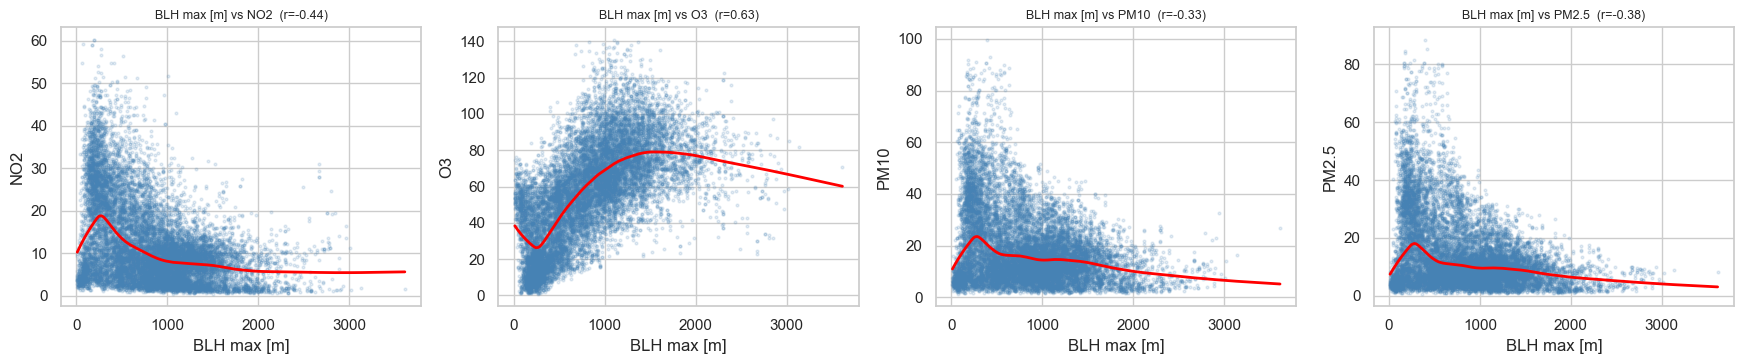

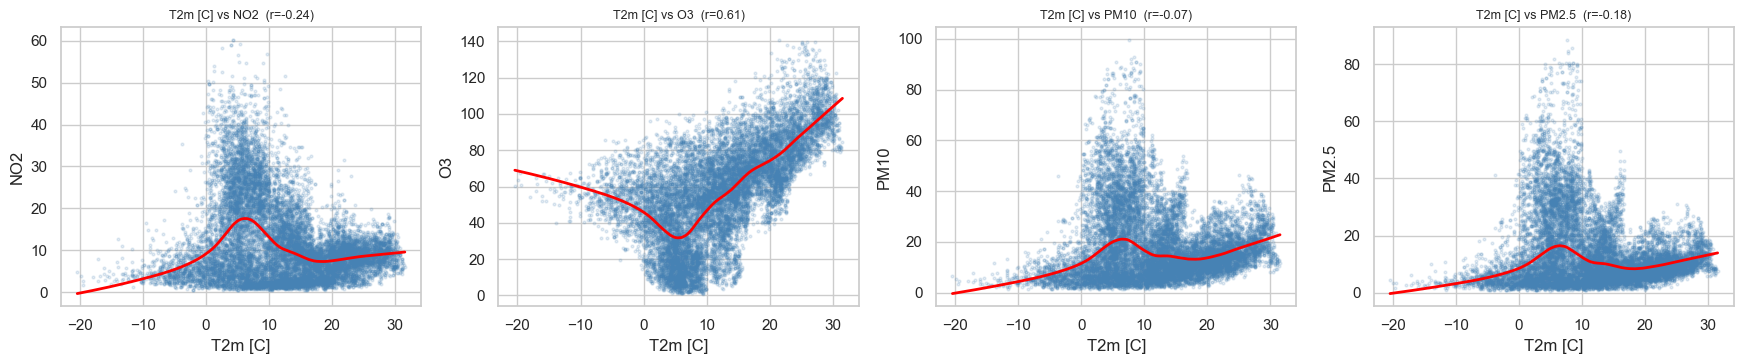

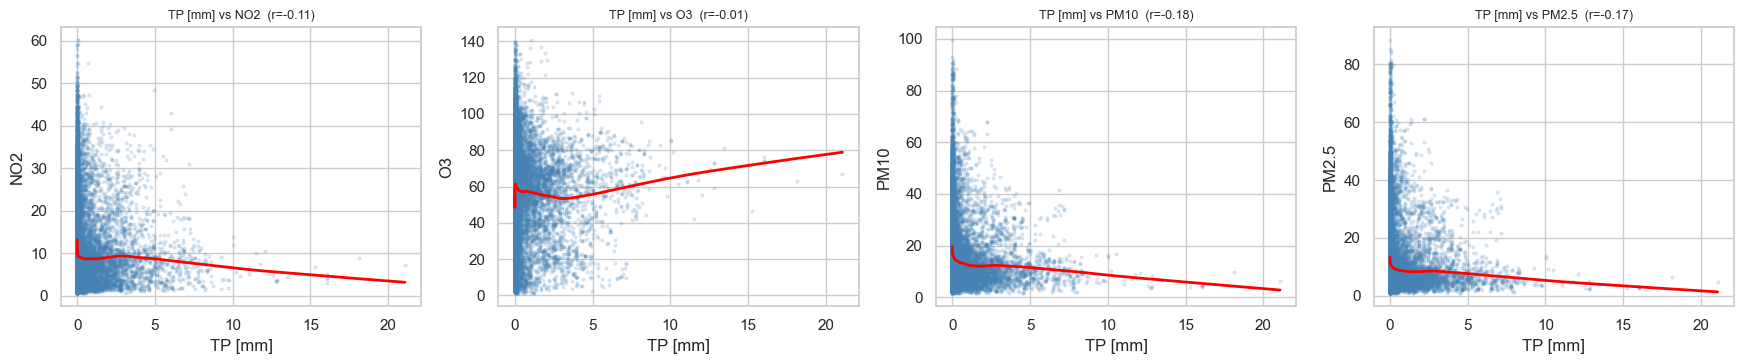

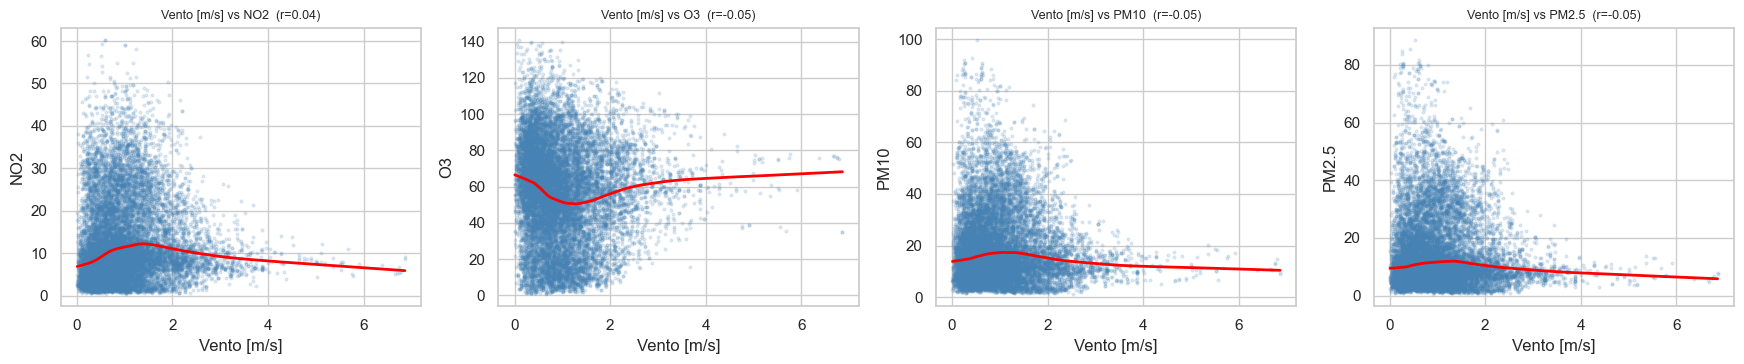

In [62]:
rng = np.random.default_rng(1)
base = df[PRED + POLL].dropna()
samp = base.iloc[rng.choice(len(base), min(15000, len(base)), replace=False)]

for p in PRED:
    fig, axes = plt.subplots(1, len(POLL), figsize=(4.4*len(POLL), 3.8))
    for ax, q in zip(axes, POLL):
        ax.scatter(samp[p], samp[q], s=4, alpha=0.15, color="steelblue")
        lo = lowess(samp[q], samp[p], frac=0.3, return_sorted=True)
        ax.plot(lo[:,0], lo[:,1], color="red", lw=2)
        r = pearson_cols(samp, p, q)
        ax.set_title(f"{ETICHETTE[p]} vs {ETICHETTE[q]}  (r={r:.2f})", fontsize=9)
        ax.set_xlabel(ETICHETTE[p]); ax.set_ylabel(ETICHETTE[q])
    plt.tight_layout(); plt.show()

## 7. Collinearit&agrave; tra predittori

Cosa facciamo e come si legge:

- **Matrice di correlazione tra i soli predittori ERA5.**
- **VIF (Variance Inflation Factor).** Regola pratica: VIF > 5 indica collinearit&agrave; da tenere
  d'occhio, VIF > 10 collinearit&agrave; forte. Attenzione attesa: `BLH`, `BLH max`, `SSRD` e `T2m`
  condividono la stessa stagionalit&agrave; e tenderanno ad avere VIF elevati.

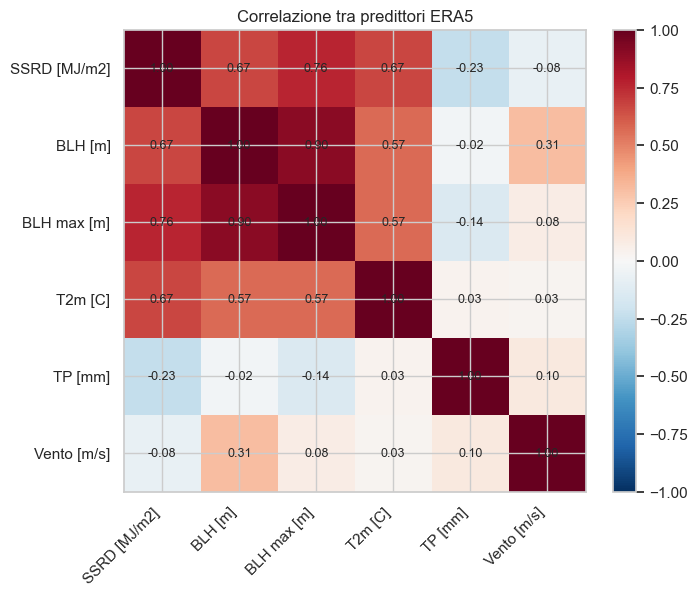

In [28]:
predcorr = df[PRED].corr("pearson")
fig, ax = plt.subplots(figsize=(7,6))
im = ax.imshow(predcorr.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(PRED))); ax.set_xticklabels([ETICHETTE[c] for c in PRED], rotation=45, ha="right")
ax.set_yticks(range(len(PRED))); ax.set_yticklabels([ETICHETTE[c] for c in PRED])
for i in range(len(PRED)):
    for j in range(len(PRED)):
        ax.text(j, i, f"{predcorr.values[i,j]:.2f}", ha="center", va="center", fontsize=9)
ax.set_title("Correlazione tra predittori ERA5"); fig.colorbar(im, fraction=0.046); plt.show()

In [29]:
Xv = df[PRED].dropna()
Xc = add_constant(Xv, has_constant="add")
vif = pd.DataFrame({
    "predittore": Xc.columns,
    "VIF": [variance_inflation_factor(Xc.values, i) for i in range(Xc.shape[1])]
})
vif = vif[vif["predittore"] != "const"].reset_index(drop=True)
vif["VIF"] = vif["VIF"].round(2)
display(vif.sort_values("VIF", ascending=False))
vif.to_csv(OUT_DIR / "vif_predittori.csv", index=False, sep=";", decimal=",")
print("Salvato:", OUT_DIR / "vif_predittori.csv")

,predittore,VIF
2,era5_blh_max,8.9200
1,era5_blh,8.8700
0,era5_ssrd_MJ,3.3900
3,era5_t2m_C,2.0300
5,vento_velocita,1.5600
4,era5_tp_mm,1.1900


Salvato: risultati_correlazione\vif_predittori.csv


## 8. Sintesi finale

Tabella riassuntiva pronta per una presentazione. Per ogni coppia predittore-inquinante:

- **segno atteso dalla fisica** dell'atmosfera,
- **segno osservato** (dal Pearson grezzo a lag 0),
- **coerenza** (atteso == osservato),
- il valore di `r` grezzo e di `r` sulle anomalie (per ricordare quanto pesa la stagionalit&agrave;).

I segni attesi sono indicativi; per PM vs T2m il segno &egrave; ambiguo (relazione a U) ed &egrave; marcato
come `~`. Un mancato accordo non implica un errore: pu&ograve; segnalare non linearit&agrave; o l'accoppiamento
interno ERA5-CAMS (vedi Avvertenze).

In [30]:
# Segni attesi dalla fisica (None/"~" = ambiguo o dipendente dalla stagione)
ATTESO = {
    ("era5_ssrd_MJ","cams_no2"): -1, ("era5_ssrd_MJ","cams_o3"): +1,
    ("era5_ssrd_MJ","cams_pm10"): -1, ("era5_ssrd_MJ","cams_pm25"): -1,
    ("era5_blh","cams_no2"): -1, ("era5_blh","cams_o3"): +1,
    ("era5_blh","cams_pm10"): -1, ("era5_blh","cams_pm25"): -1,
    ("era5_blh_max","cams_no2"): -1, ("era5_blh_max","cams_o3"): +1,
    ("era5_blh_max","cams_pm10"): -1, ("era5_blh_max","cams_pm25"): -1,
    ("era5_t2m_C","cams_no2"): -1, ("era5_t2m_C","cams_o3"): +1,
    ("era5_t2m_C","cams_pm10"): 0, ("era5_t2m_C","cams_pm25"): 0,   # 0 = a U / ambiguo
    ("era5_tp_mm","cams_no2"): -1, ("era5_tp_mm","cams_o3"): -1,
    ("era5_tp_mm","cams_pm10"): -1, ("era5_tp_mm","cams_pm25"): -1,
    ("vento_velocita","cams_no2"): -1, ("vento_velocita","cams_o3"): 0,
    ("vento_velocita","cams_pm10"): -1, ("vento_velocita","cams_pm25"): -1,
}
def sign_str(v):
    return "~" if v == 0 else ("+" if v > 0 else "-")

r_lookup = {(r.predittore, r.inquinante): (r.r_grezzo, r.r_anomalie)
            for r in season_df.itertuples()}

rows = []
for p in PRED:
    for q in POLL:
        att = ATTESO.get((p, q), 0)
        r_raw, r_an = r_lookup[(p, q)]
        oss = 0 if (r_raw is None or np.isnan(r_raw)) else int(np.sign(r_raw))
        coerente = ("n/d (ambiguo)" if att == 0
                    else ("SI" if oss == att else "NO"))
        rows.append({
            "predittore": ETICHETTE[p], "inquinante": ETICHETTE[q],
            "segno_atteso": sign_str(att), "segno_osservato": sign_str(oss),
            "coerenza": coerente,
            "r_grezzo": r_raw, "r_anomalie": r_an,
        })
sintesi = pd.DataFrame(rows)
display(sintesi)
sintesi.to_csv(OUT_DIR / "sintesi_finale.csv", index=False, sep=";", decimal=",")
print("Salvato:", OUT_DIR / "sintesi_finale.csv")

,predittore,inquinante,segno_atteso,segno_osservato,coerenza,r_grezzo,r_anomalie
0,SSRD [MJ/m2],NO2,-,-,SI,-0.4665,-0.0140
1,SSRD [MJ/m2],O3,+,+,SI,0.8040,0.4579
2,SSRD [MJ/m2],PM10,-,-,SI,-0.2724,0.0775
3,SSRD [MJ/m2],PM2.5,-,-,SI,-0.3474,0.0604
4,BLH [m],NO2,-,-,SI,-0.4306,-0.3403
5,BLH [m],O3,+,+,SI,0.6100,0.2314
6,BLH [m],PM10,-,-,SI,-0.3325,-0.2933
7,BLH [m],PM2.5,-,-,SI,-0.3807,-0.2962
8,BLH max [m],NO2,-,-,SI,-0.4453,-0.2212
9,BLH max [m],O3,+,+,SI,0.6398,0.2785


Salvato: risultati_correlazione\sintesi_finale.csv


### Promemoria di lettura

- I coefficienti alti a **media mobile lunga** (Sez. 4) sono **gonfiati** dall'autocorrelazione:
  non sono potere predittivo giornaliero.
- Il salto tra `r_grezzo` e `r_anomalie` (Sez. 5 e 8) misura **quanta parte** della correlazione
  era solo **stagionalit&agrave; condivisa**.
- `ssrd`, `tp` e `blh_max` sono **proxy** costruiti su 4 istanti giornalieri.
- **ERA5 e CAMS non sono indipendenti**: queste correlazioni guidano la scelta dei predittori,
  non dimostrano una relazione causale osservata.
- L'**umidit&agrave; relativa** non &egrave; nel dataset: limitazione dichiarata, non stimata.
- Un `r` basso **non** basta a escludere un predittore dal modello.

## 9. Modello finale ed errore

Chiusa l'analisi esplorativa, costruiamo un **modello di regressione lineare multipla** che stima
ogni inquinante CAMS a partire dai predittori ERA5, ne scriviamo l'**equazione esplicita** e ne
**quantifichiamo l'errore**.

**Scelte del modello (motivate dalle sezioni precedenti):**

- **Un modello per inquinante** (`NO2`, `O3`, `PM10`, `PM2.5`): stessa struttura, coefficienti
  diversi.
- **Predittori:** `era5_ssrd_MJ`, `1/era5_blh` (forma inversa fisica, Sez. 6a), `era5_t2m_C`,
  `era5_tp_mm`, `vento_velocita`. Escludiamo `era5_blh_max` per la forte collinearit&agrave; con `BLH`
  (Sez. 7).
- **Unit&agrave; originali** (non standardizzate) nell'equazione, per renderla interpretabile; a parte
  riportiamo i **coefficienti standardizzati** (`beta`) per confrontare l'importanza dei predittori.

**Come misuriamo l'errore:**

- **In-sample** (R&sup2;, RMSE, MAE, bias, MAPE): utile ma **ottimistico**.
- **Cross-validation leave-one-month-out (LOMO):** si addestra su 11 mesi e si prevede il mese
  escluso, a rotazione. Tenendo **interi mesi** fuori dal training si rimuove il *leakage* da
  **autocorrelazione temporale** (i vicini dello stesso giorno non finiscono nel training),
  quindi l'errore LOMO &egrave; la stima **onesta** di quanto il modello generalizza.

> &#9888;&#65039; **Che cosa misura questo errore.** Il modello riproduce l'**output di CAMS**, non le
> concentrazioni realmente misurate. Un R&sup2; alto significa che pochi predittori ERA5 spiegano
> gran parte di ci&ograve; che CAMS gi&agrave; calcola dalla stessa meteorologia (Avvertenza 1): &egrave; una
> **emulazione**, non una validazione contro osservazioni indipendenti. Un R&sup2; basso su un
> inquinante (tipicamente O3/PM) indica che la meteo da sola non basta e servono chimica,
> emissioni o termini non lineari/ritardati.

In [31]:
import statsmodels.api as sm
from IPython.display import Math

# Predittori del modello (forma inversa della BLH; blh_max escluso per collinearita')
df["inv_blh"] = 1.0 / df["era5_blh"].where(df["era5_blh"] > 0)
FEATURES_MODELLO = ["era5_ssrd_MJ", "inv_blh", "era5_t2m_C", "era5_tp_mm", "vento_velocita"]

# Simboli compatti per l'equazione (unita' tra parentesi)
SIMB = {
    "const": "", "era5_ssrd_MJ": "SSRD", "inv_blh": "(1/BLH)",
    "era5_t2m_C": "T2m", "era5_tp_mm": "TP", "vento_velocita": "WS",
}

def metriche(y_true, y_pred):
    yt = np.asarray(y_true, float); yp = np.asarray(y_pred, float)
    e = yp - yt
    ss_res = float((e**2).sum()); ss_tot = float(((yt - yt.mean())**2).sum())
    r2 = 1 - ss_res/ss_tot if ss_tot > 0 else np.nan
    nz = yt != 0
    mape = float(np.abs(e[nz]/yt[nz]).mean()*100) if nz.any() else np.nan
    return {"n": len(yt), "R2": r2, "RMSE": float(np.sqrt((e**2).mean())),
            "MAE": float(np.abs(e).mean()), "Bias": float(e.mean()), "MAPE_%": mape}

print("Predittori del modello:", FEATURES_MODELLO)

Predittori del modello: ['era5_ssrd_MJ', 'inv_blh', 'era5_t2m_C', 'era5_tp_mm', 'vento_velocita']


In [32]:
# Stima del modello per ogni inquinante: fit su tutti i dati (equazione finale)
# + errore in-sample + errore in cross-validation leave-one-month-out (LOMO).
modelli = {}
eq_rows, coef_rows, err_rows = [], [], []

for q in POLL:
    d = df[["mese"] + FEATURES_MODELLO + [q]].dropna().copy()
    X = sm.add_constant(d[FEATURES_MODELLO]); y = d[q]

    # --- fit finale su tutti i dati ---
    m = sm.OLS(y, X).fit()
    modelli[q] = m
    ins = metriche(y, m.fittedvalues); ins.update({"inquinante": ETICHETTE[q], "tipo": "in-sample"})

    # --- CV leave-one-month-out (errore onesto) ---
    pred_cv = pd.Series(index=d.index, dtype=float)
    for mo in sorted(d["mese"].unique()):
        tr = d["mese"] != mo
        mm = sm.OLS(y[tr], X[tr]).fit()
        pred_cv[~tr] = mm.predict(X[~tr]).values
    cv = metriche(y, pred_cv); cv.update({"inquinante": ETICHETTE[q], "tipo": "CV LOMO"})
    err_rows += [ins, cv]

    # --- equazione in unita' originali ---
    p = m.params
    termini = [f"{p['const']:+.4g}"] + [f"{p[f]:+.4g}*{f}" for f in FEATURES_MODELLO]
    eq_rows.append({"inquinante": ETICHETTE[q], "equazione": f"{q}_hat = " + " ".join(termini),
                    "R2_in_sample": round(ins["R2"], 3), "R2_CV_LOMO": round(cv["R2"], 3),
                    "RMSE_CV": round(cv["RMSE"], 3)})

    # --- coefficienti: grezzi, p-value e standardizzati (beta) ---
    beta = m.params[FEATURES_MODELLO] * d[FEATURES_MODELLO].std() / y.std()
    for f in FEATURES_MODELLO:
        coef_rows.append({"inquinante": ETICHETTE[q], "predittore": f,
                          "coef": round(float(m.params[f]), 5),
                          "p_value": round(float(m.pvalues[f]), 4),
                          "beta_std": round(float(beta[f]), 4)})

eq_df = pd.DataFrame(eq_rows)
coef_df = pd.DataFrame(coef_rows)
err_df = pd.DataFrame(err_rows)[["inquinante","tipo","n","R2","RMSE","MAE","Bias","MAPE_%"]]
print("Modelli stimati:", list(modelli.keys()))

Modelli stimati: ['cams_no2', 'cams_o3', 'cams_pm10', 'cams_pm25']


In [33]:
# Equazioni finali (forma leggibile) + rendering LaTeX
display(eq_df[["inquinante","equazione","R2_in_sample","R2_CV_LOMO"]])

def eq_latex(m, sym):
    p = m.params
    parts = [f"{p['const']:.4g}"]
    for f in FEATURES_MODELLO:
        parts.append(f"{p[f]:+.4g}\\,\\mathrm{{{SIMB[f]}}}")
    return r"\widehat{\mathrm{%s}} = " % sym + " ".join(parts)

for q in POLL:
    display(Math(eq_latex(modelli[q], ETICHETTE[q].replace('.', '_'))))

,inquinante,equazione,R2_in_sample,R2_CV_LOMO
0,NO2,cams_no2_hat = +22.21 -5.546*era5_ssrd_MJ -15....,0.2980,0.2450
1,O3,cams_o3_hat = +11.43 +18.18*era5_ssrd_MJ +142*...,0.6830,0.6560
2,PM10,cams_pm10_hat = +29.74 -6.528*era5_ssrd_MJ -0....,0.1960,0.1170
3,PM2.5,cams_pm25_hat = +26.26 -5.822*era5_ssrd_MJ -37...,0.2130,0.1290


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [34]:
# Tabella coefficienti (importanza = |beta standardizzato|)
coef_pivot = coef_df.pivot(index="predittore", columns="inquinante", values="beta_std")
coef_pivot = coef_pivot.reindex(FEATURES_MODELLO)
print("Coefficienti standardizzati (beta) - importanza relativa dei predittori:")
display(coef_pivot)
print("\nDettaglio coefficienti, p-value e beta:")
display(coef_df)

# Summary statistico completo di un modello di esempio (PM10)
print("\n--- Summary OLS di esempio: PM10 ---")
print(modelli["cams_pm10"].summary())

Coefficienti standardizzati (beta) - importanza relativa dei predittori:


inquinante,NO2,O3,PM10,PM2.5
predittore,,,,
era5_ssrd_MJ,-0.6927,0.8067,-0.5716,-0.5708
inv_blh,-0.0122,0.0409,-0.0004,-0.0237
era5_t2m_C,0.2321,0.0832,0.3257,0.2062
era5_tp_mm,-0.2828,0.1778,-0.3241,-0.3030
vento_velocita,0.0074,0.0035,-0.0663,-0.0691



Dettaglio coefficienti, p-value e beta:


,inquinante,predittore,coef,p_value,beta_std
0,NO2,era5_ssrd_MJ,-5.5457,0.0000,-0.6927
1,NO2,inv_blh,-15.0925,0.0000,-0.0122
2,NO2,era5_t2m_C,0.2587,0.0000,0.2321
3,NO2,era5_tp_mm,-2.0063,0.0000,-0.2828
4,NO2,vento_velocita,0.0984,0.0000,0.0074
5,O3,era5_ssrd_MJ,18.1775,0.0000,0.8067
6,O3,inv_blh,142.0364,0.0000,0.0409
7,O3,era5_t2m_C,0.2610,0.0000,0.0832
8,O3,era5_tp_mm,3.5507,0.0000,0.1778
9,O3,vento_velocita,0.1324,0.0000,0.0035



--- Summary OLS di esempio: PM10 ---
                            OLS Regression Results                            
Dep. Variable:              cams_pm10   R-squared:                       0.196
Model:                            OLS   Adj. R-squared:                  0.196
Method:                 Least Squares   F-statistic:                 2.203e+04
Date:                Mon, 27 Jul 2026   Prob (F-statistic):               0.00
Time:                        12:43:07   Log-Likelihood:            -1.7790e+06
No. Observations:              452816   AIC:                         3.558e+06
Df Residuals:                  452810   BIC:                         3.558e+06
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const 

In [35]:
# Tabella errori e salvataggio CSV
print("Errore del modello (in-sample vs CV leave-one-month-out):")
display(err_df.round(4))

eq_df.to_csv(OUT_DIR / "modello_equazioni.csv", index=False, sep=";", decimal=",")
coef_df.to_csv(OUT_DIR / "modello_coefficienti.csv", index=False, sep=";", decimal=",")
err_df.to_csv(OUT_DIR / "modello_errori.csv", index=False, sep=";", decimal=",")
print("Salvati: modello_equazioni.csv, modello_coefficienti.csv, modello_errori.csv")

Errore del modello (in-sample vs CV leave-one-month-out):


,inquinante,tipo,n,R2,RMSE,MAE,Bias,MAPE_%
0,NO2,in-sample,452816,0.2977,8.0581,6.1635,-0.0000,98.0332
1,NO2,CV LOMO,452816,0.2452,8.3542,6.4027,-0.0494,101.2132
2,O3,in-sample,452816,0.6830,15.2363,12.5078,-0.0000,48.1188
3,O3,CV LOMO,452816,0.6561,15.8707,13.0197,-0.0639,50.8376
4,PM10,in-sample,452816,0.1957,12.3018,9.2265,-0.0000,81.7643
5,PM10,CV LOMO,452816,0.1169,12.8899,9.7068,-0.0771,85.6483
6,PM2.5,in-sample,451572,0.2127,10.8782,7.9656,-0.0000,102.7322
7,PM2.5,CV LOMO,451572,0.1285,11.4451,8.4110,-0.0719,108.3038


Salvati: modello_equazioni.csv, modello_coefficienti.csv, modello_errori.csv


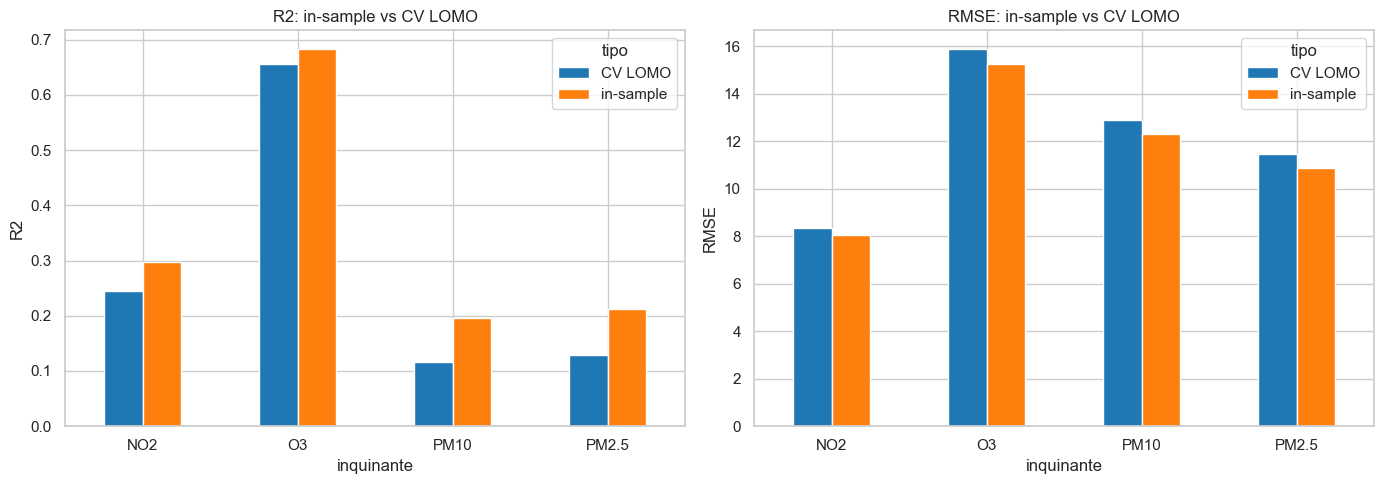

In [36]:
# Confronto grafico: R2 e RMSE, in-sample vs CV LOMO
piv_r2 = err_df.pivot(index="inquinante", columns="tipo", values="R2").reindex([ETICHETTE[q] for q in POLL])
piv_rmse = err_df.pivot(index="inquinante", columns="tipo", values="RMSE").reindex([ETICHETTE[q] for q in POLL])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
piv_r2.plot(kind="bar", ax=axes[0], color=["tab:blue","tab:orange"])
axes[0].set_title("R2: in-sample vs CV LOMO"); axes[0].set_ylabel("R2"); axes[0].axhline(0, color="k", lw=0.8)
axes[0].tick_params(axis="x", rotation=0)
piv_rmse.plot(kind="bar", ax=axes[1], color=["tab:blue","tab:orange"])
axes[1].set_title("RMSE: in-sample vs CV LOMO"); axes[1].set_ylabel("RMSE"); axes[1].tick_params(axis="x", rotation=0)
plt.tight_layout(); plt.show()

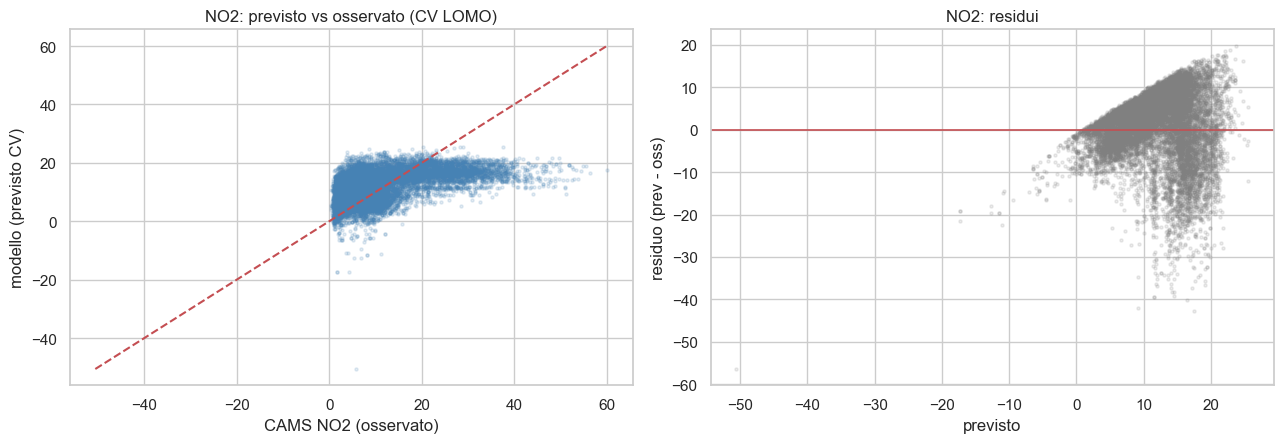

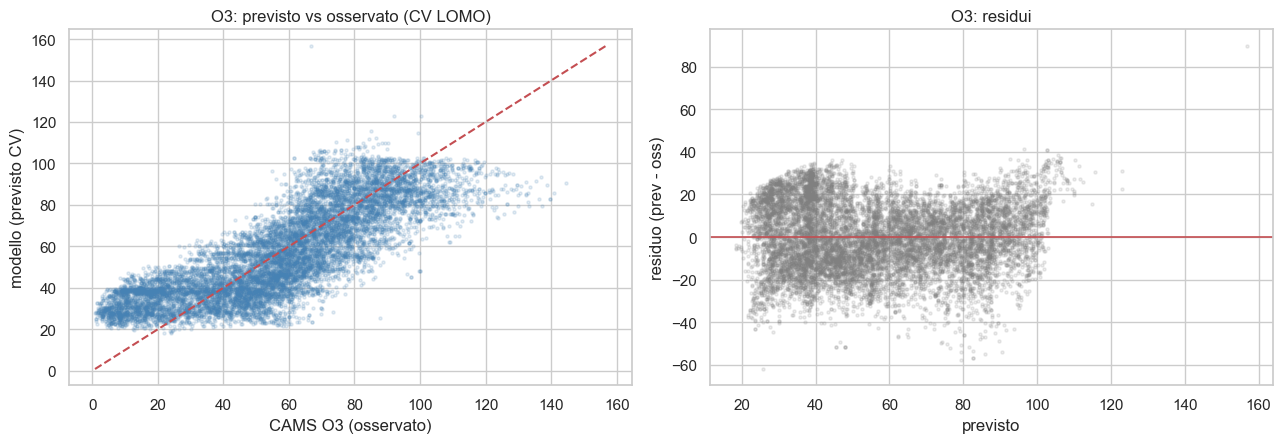

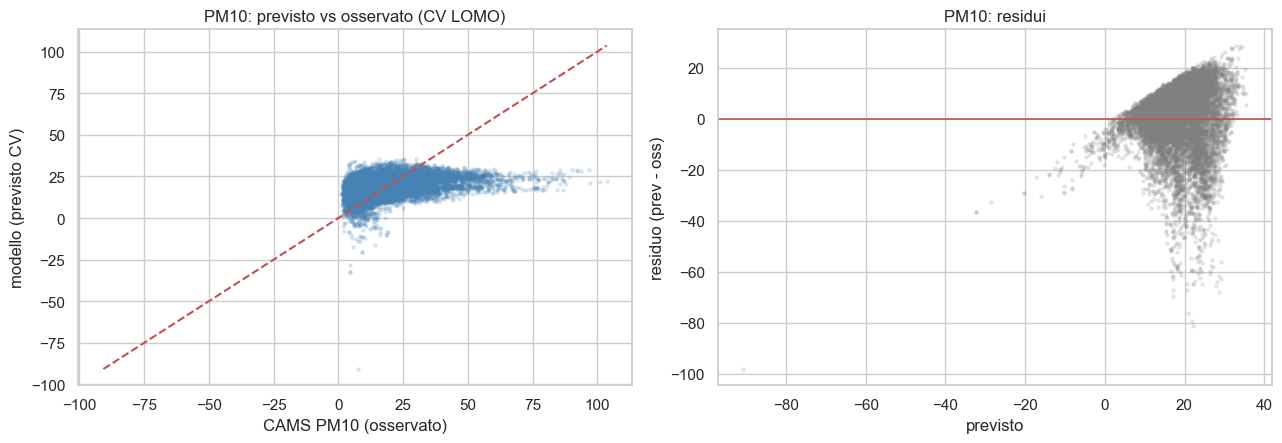

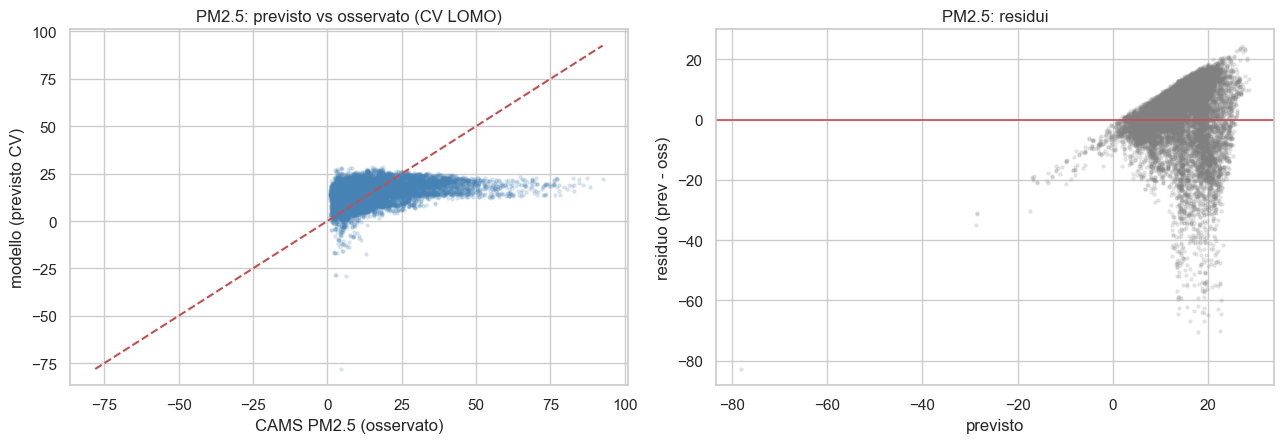

In [37]:
# Diagnostica per inquinante: osservato (CAMS) vs previsto in CV + residui
for q in POLL:
    d = df[["mese"] + FEATURES_MODELLO + [q]].dropna().copy()
    X = sm.add_constant(d[FEATURES_MODELLO]); y = d[q]
    pred = pd.Series(index=d.index, dtype=float)
    for mo in sorted(d["mese"].unique()):
        tr = d["mese"] != mo
        pred[~tr] = sm.OLS(y[tr], X[tr]).fit().predict(X[~tr]).values

    rng = np.random.default_rng(2)
    idx = rng.choice(len(d), min(12000, len(d)), replace=False)
    yy, pp = y.values[idx], pred.values[idx]

    fig, ax = plt.subplots(1, 2, figsize=(13, 4.6))
    ax[0].scatter(yy, pp, s=5, alpha=0.15, color="steelblue")
    lim = [min(yy.min(), pp.min()), max(yy.max(), pp.max())]
    ax[0].plot(lim, lim, "r--", lw=1.5)
    ax[0].set_xlabel(f"CAMS {ETICHETTE[q]} (osservato)"); ax[0].set_ylabel("modello (previsto CV)")
    ax[0].set_title(f"{ETICHETTE[q]}: previsto vs osservato (CV LOMO)")
    resid = pp - yy
    ax[1].scatter(pp, resid, s=5, alpha=0.15, color="grey"); ax[1].axhline(0, color="r", lw=1.2)
    ax[1].set_xlabel("previsto"); ax[1].set_ylabel("residuo (prev - oss)")
    ax[1].set_title(f"{ETICHETTE[q]}: residui")
    plt.tight_layout(); plt.show()

### Come leggere il modello e il suo errore

- **Equazione** (unit&agrave; originali): il segno e la grandezza di ogni coefficiente vanno letti a
  parit&agrave; degli altri predittori. Per confrontare l'**importanza** usare i **coefficienti
  standardizzati** (`beta`), non i coefficienti grezzi (che dipendono dalle unit&agrave;).
- **R&sup2; in-sample vs CV LOMO:** se l'R&sup2; in CV crolla rispetto all'in-sample, il modello
  **sovra-adatta**; se restano vicini, la relazione &egrave; stabile tra i mesi.
- **RMSE / MAE:** errore nelle **stesse unit&agrave;** dell'inquinante (confrontabile con la sua media,
  vedi Sez. 2). **Bias** ~0 indica assenza di sistematica sotto/sovrastima.
- **Residui vs previsto:** una struttura a imbuto o curva segnala **non linearit&agrave;/eteroschedasticit&agrave;**
  residua: possibili miglioramenti sono termini quadratici (es. `T2m^2` per il PM, Sez. 6c),
  predittori ritardati (Sez. 4) o modelli non lineari.
- **Ricordare:** l'errore &egrave; calcolato **rispetto a CAMS**, non a misure reali; ERA5 e CAMS non
  sono indipendenti (Avvertenza 1). Questo modello quantifica *quanta parte di CAMS &egrave;
  spiegabile dalla meteo ERA5*, come sintesi finale della fase esplorativa.